In [ ]:
# Cell 0 - Configuration
# Centralized hyperparameters, paths, and training constants.
import os
from pathlib import Path
import torch

# Environment
IS_KAGGLE  = os.path.exists("/kaggle/input")
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
KAGGLE_DATASET_SLUG = "BDC2026-20260704T072647Z-3-001"

# Data Constants
N_SPLITS   = 5
SEED       = 42
NUM_WORKERS= 4

OVERWRITE_MANIFEST = True  

MODEL_NAME_CNN = "convnextv2_tiny.fcmae_ft_in22k_in1k"
MODEL_NAME_VIT = "vit_small_patch14_dinov2.lvd142m"

IMG_SIZE_CNN = 384
IMG_SIZE_VIT = 518

BATCH_SIZE_CNN = 32
BATCH_SIZE_VIT = 16  

# ConvNeXt Hyperparameters
BACKBONE_LR_CNN = 1e-5
EMA_DECAY_CNN    = 0.999

# DINOv2 Hyperparameters 
BACKBONE_LR_VIT = 5e-6  
EMA_DECAY_VIT    = 0.9995 

# Shared Hyperparameters
HEAD_LR            = 1e-4
WEIGHT_DECAY       = 0.05
NUM_EPOCHS         = 40
WARMUP_STEPS_RATIO = 0.075

# Regularization
LABEL_SMOOTHING    = 0.1

ENSEMBLE_WEIGHT_CNN = 0.5
ENSEMBLE_WEIGHT_VIT = 0.5

# Class Mapping
CLASS_FOLDERS = ["0_Recyclable", "1_Electronic", "2_Organic"]
LABEL_MAP     = {0: "Recyclable", 1: "Electronic", 2: "Organic"}
LABEL_TO_IDX  = {"0_Recyclable": 0, "1_Electronic": 1, "2_Organic": 2}  

# Data Integrity Constants
EXPECTED_TRAIN_COUNT      = 26527
EXPECTED_TEST_COUNT       = 1458
EXPECTED_OVERLAP_COUNT    = 97
EXPECTED_NEAR_DUP_COUNT   = 2
EXPECTED_TRAINING_EXCLUDE = 57  
EXPECTED_CV_EXCLUDE       = 97
EXPECTED_CV_POOL_SIZE     = 26373  
INITIAL_MISLABEL_EXCLUDE_FILES = {"O_8873.jpg"}

# Training Stability
GRADIENT_CLIP_NORM      = 1.0
EARLY_STOPPING_PATIENCE = 7
EARLY_STOPPING_MIN_DELTA = 0.0005

# Inference Options
TTA_PASSES_CNN = 8  
TTA_PASSES_VIT = 5  
SAVE_PERIODIC_CHECKPOINTS = False  
CHECKPOINT_EVERY_N_EPOCHS = 3

# Run identifier
RUN_ID = f"satria_v6_ensemble_{NUM_EPOCHS}ep_seed{SEED}"

print(f"Config loaded. Execution Device: {DEVICE.upper()}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"OVERWRITE_MANIFEST: {OVERWRITE_MANIFEST}")

Config loaded. Execution Device: CUDA
GPU: NVIDIA GeForce RTX 5070 Ti
VRAM: 16.62 GB
OVERWRITE_MANIFEST: True


In [ ]:
# Cell 1 - Environment Setup
import shutil

def find_train_dir(root: Path):
    """Recursively search for a 'train' folder under root, return its parent."""
    if not root.exists():
        return None
    for check_dir in root.rglob("*"):
        if check_dir.is_dir() and check_dir.name == "train":
            return check_dir.parent
    return None

if IS_KAGGLE:
    input_root = Path("/kaggle/input")
    candidate_root = input_root / KAGGLE_DATASET_SLUG
    DATA_DIR = None

    if candidate_root.exists():
        DATA_DIR = find_train_dir(candidate_root)
        if DATA_DIR is None:
            DATA_DIR = candidate_root

    if DATA_DIR is None or not (DATA_DIR / "train").exists():
        for d in input_root.iterdir():
            found = find_train_dir(d)
            if found is not None:
                DATA_DIR = found
                break

    if DATA_DIR is None:
        print("DEBUG: Could not locate 'train' folder. Contents of /kaggle/input:")
        for d in input_root.iterdir():
            print(f"  {d}")
        raise FileNotFoundError("Could not auto-detect DATA_DIR.")
            
    OUTPUT_DIR = Path("/kaggle/working")
else:
    current_dir = Path.cwd()
    DATA_DIR = None
    check_dir = current_dir
    while check_dir != check_dir.parent:
        if "satria-data-bdc" in check_dir.name.lower():
            DATA_DIR = check_dir
            break
        check_dir = check_dir.parent

    if DATA_DIR is None:
        DATA_DIR = current_dir

    OUTPUT_DIR = DATA_DIR / "outputs"
    OUTPUT_DIR.mkdir(exist_ok=True)

# Derive subdirs
TRAIN_DIR       = DATA_DIR / "train"
TEST_DIR        = DATA_DIR / "test"
SUBMISSION_PATH = DATA_DIR / "submission.csv"

# Validate paths
assert TRAIN_DIR.exists(), f"TRAIN_DIR not found: {TRAIN_DIR}"
assert TEST_DIR.exists(),  f"TEST_DIR not found: {TEST_DIR}"
assert SUBMISSION_PATH.exists(), f"submission.csv not found: {SUBMISSION_PATH}"

print(f"Environment  : {'Kaggle' if IS_KAGGLE else 'Local'}")
print(f"DATA_DIR     : {DATA_DIR}")
print(f"OUTPUT_DIR   : {OUTPUT_DIR}")
print(f"Train files  : {len(list(TRAIN_DIR.rglob('*.*'))):,}")
print(f"Test files   : {len(list(TEST_DIR.rglob('*.*'))):,}")

Environment  : Local
DATA_DIR     : /workspace/satria-data-bdc
OUTPUT_DIR   : /workspace/satria-data-bdc/outputs
Train files  : 26,527
Test files   : 1,458


In [3]:
# Cell 2 - Library Imports
# Centralized imports, logging configuration, and reproducibility seeding.
import sys
import copy
import json
import time
import math
import random
import warnings
import logging
import tempfile
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

import timm
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold
from tqdm.auto import tqdm
import cv2
import hashlib
import re

# Configuration for robustness
warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Logging setup
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)

# Seed everything for full reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

# Library version assertions
assert torch.__version__ >= "2.0.0", f"PyTorch {torch.__version__} is too old - need >= 2.0 for amp.autocast API"
assert timm.__version__ >= "0.9.0", f"timm {timm.__version__} is too old - ConvNeXtV2/DINOv2 requires >= 0.9"

print(f"Libraries loaded.")
print(f"  torch  : {torch.__version__}")
print(f"  timm   : {timm.__version__}")

Libraries loaded.
  torch  : 2.11.0+cu128
  timm   : 1.0.28


In [ ]:
# Cell 3 - MD5 Duplicate Detection
# Detects train-test overlap and within-train exact/near duplicates via MD5 hashing.

def compute_file_hash(file_path, chunk_size=8192):
    hasher = hashlib.md5()
    with open(file_path, "rb") as f:
        while chunk := f.read(chunk_size):
            hasher.update(chunk)
    return hasher.hexdigest()

def hash_all(root_dirs: dict, exts=None):
    if exts is None:
        exts = {".jpg", ".jpeg", ".png"}

    hash_map = defaultdict(list)
    all_files = []

    for label, folder in root_dirs.items():
        folder = Path(folder)
        for fp in sorted(folder.rglob("*")):
            if fp.is_file() and fp.suffix.lower() in exts:
                h = compute_file_hash(fp)
                hash_map[h].append((label, str(fp)))
                all_files.append((label, fp))

    return hash_map, all_files

TRAIN_DIRS = {
    "0_Recyclable": DATA_DIR / "train" / "0_Recyclable",
    "1_Electronic": DATA_DIR / "train" / "1_Electronic",
    "2_Organic":    DATA_DIR / "train" / "2_Organic",
}
TEST_DIR_MAP = {"test": DATA_DIR / "test"}

OVERLAP_CSV     = OUTPUT_DIR / "train_test_overlap.csv"
DUP_GROUPS_CSV  = OUTPUT_DIR / "train_duplicate_groups.csv"
NEAR_DUP_CSV    = OUTPUT_DIR / "near_duplicate_candidates.csv"

# Check OVERWRITE_MANIFEST flag
if not OVERWRITE_MANIFEST and OVERLAP_CSV.exists() and DUP_GROUPS_CSV.exists() and NEAR_DUP_CSV.exists():
    print("Loading pre-computed duplicate CSVs (OVERWRITE_MANIFEST=False)...")
    overlap_df   = pd.read_csv(OVERLAP_CSV)
    groups_df    = pd.read_csv(DUP_GROUPS_CSV)
    near_dup_df  = pd.read_csv(NEAR_DUP_CSV)
else:
    if OVERWRITE_MANIFEST:
        print("OVERWRITE_MANIFEST=True. Forcing hash recomputation from scratch...")
    else:
        print("Computing hashes from scratch (this may take a few minutes)...")
        
    print("  Hashing train...")
    train_hashes, train_files = hash_all(TRAIN_DIRS)
    print("  Hashing test...")
    test_hashes, _            = hash_all(TEST_DIR_MAP)

    overlap_rows = []
    for h, train_entries in train_hashes.items():
        if h in test_hashes:
            for (train_label, train_path) in train_entries:
                for (_, test_path) in test_hashes[h]:
                    overlap_rows.append({
                        "md5":            h,
                        "train_label":    train_label,
                        "train_path":     train_path,
                        "train_filename": Path(train_path).name,
                        "test_path":      test_path,
                        "test_id":        int(Path(test_path).stem),
                    })
    overlap_df = pd.DataFrame(overlap_rows)
    overlap_df.to_csv(OVERLAP_CSV, index=False)

    group_rows = []
    group_id   = 0
    for h, entries in train_hashes.items():
        if len(entries) > 1:
            group_id += 1
            labels_in_group = set(label for label, _ in entries)
            is_cross_class  = len(labels_in_group) > 1
            for (label, path) in entries:
                group_rows.append({
                    "md5":                h,
                    "duplicate_group_id": group_id,
                    "label":              label,
                    "filepath":           path,
                    "filename":           Path(path).name,
                    "is_cross_class_group": is_cross_class,
                    "match_type":         "exact_md5",
                })
    groups_df = pd.DataFrame(group_rows)
    groups_df.to_csv(DUP_GROUPS_CSV, index=False)

    copy_pattern = re.compile(r"^(.*)\((\d+)\)(\.\w+)$")
    name_to_path = {fp.name: (label, fp) for label, fp in train_files}
    candidates   = []

    for label, fp in train_files:
        m = copy_pattern.match(fp.name)
        if m:
            base_name = m.group(1) + m.group(3)
            if base_name in name_to_path:
                orig_label, orig_fp = name_to_path[base_name]
                h_copy = compute_file_hash(fp)
                h_orig = compute_file_hash(orig_fp)
                candidates.append({
                    "file_a":   fp.name,
                    "file_b":   base_name,
                    "label_a":  label,
                    "label_b":  orig_label,
                    "md5_match": h_copy == h_orig,
                    "path_a":   str(fp),
                    "path_b":   str(orig_fp),
                })
    cand_df    = pd.DataFrame(candidates)
    near_dup_df = cand_df[~cand_df["md5_match"]].reset_index(drop=True) if len(cand_df) > 0 else pd.DataFrame()
    near_dup_df.to_csv(NEAR_DUP_CSV, index=False)
    print("  Done - CSVs saved.")

print(f"\nTrain-test overlap       : {len(overlap_df)} pairs  (expected {EXPECTED_OVERLAP_COUNT})")
print(f"Exact-MD5 dup groups     : {groups_df['duplicate_group_id'].nunique()} groups")
print(f"Near-duplicate candidates: {len(near_dup_df)} pairs  (expected {EXPECTED_NEAR_DUP_COUNT})")

assert len(overlap_df) == EXPECTED_OVERLAP_COUNT, f"Train-test overlap mismatch: got {len(overlap_df)}, expected {EXPECTED_OVERLAP_COUNT}"
assert len(near_dup_df) == EXPECTED_NEAR_DUP_COUNT, f"Near-duplicate count mismatch: got {len(near_dup_df)}, expected {EXPECTED_NEAR_DUP_COUNT}"

# Ensure train_files is available for Cell 4 if loaded from cache
if 'train_files' not in locals():
    _, train_files = hash_all(TRAIN_DIRS)
    name_to_path = {fp.name: (label, fp) for label, fp in train_files}
    copy_pattern = re.compile(r"^(.*)\((\d+)\)(\.\w+)$")

orphan_copies = []
for label, fp in train_files:
    m = copy_pattern.match(fp.name)
    if m and (m.group(1) + m.group(3)) not in name_to_path:
        orphan_copies.append({"filename": fp.name, "filepath": str(fp)})

if orphan_copies:
    print(f"WARNING: Orphan copies (original missing): {len(orphan_copies)}")
    for o in orphan_copies[:10]:
        print(f"    {o['filename']}")

OVERWRITE_MANIFEST=True. Forcing hash recomputation from scratch...
  Hashing train...
  Hashing test...
  Done - CSVs saved.

Train-test overlap       : 97 pairs  (expected 97)
Exact-MD5 dup groups     : 62 groups
Near-duplicate candidates: 2 pairs  (expected 2)
    IMG-20200328-WA0048(1).jpg
    IMG_20200329_152840(1).jpg
    maxresdefault (1).jpg
    unnamed (1).jpg


In [5]:
# Cell 4 - Build Master Manifest
# Constructs the master dataframe with duplicate group IDs and exclusion flags.
NEAR_DUP_GROUP_START = 900_000

LABEL_MAP_FOLDER = {
    "0_Recyclable": 0,
    "1_Electronic":  1,
    "2_Organic":     2,
}

records = []
for folder in sorted((DATA_DIR / "train").iterdir()):
    if not folder.is_dir():
        continue
    if folder.name not in LABEL_MAP_FOLDER:
        print(f"WARNING: unexpected folder '{folder.name}' - skipped")
        continue
    label_id = LABEL_MAP_FOLDER[folder.name]
    for fp in sorted(folder.glob("*")):
        if fp.is_file():
            records.append({
                "filename":     fp.name,
                "filepath":     str(fp),
                "label":        label_id,
                "label_folder": folder.name,
            })

train_master = pd.DataFrame(records)
print(f"Total train files found: {len(train_master)}  (expected {EXPECTED_TRAIN_COUNT})")
assert len(train_master) == EXPECTED_TRAIN_COUNT, f"Row count changed! Expected {EXPECTED_TRAIN_COUNT}, got {len(train_master)}"

train_master["duplicate_group_id"] = range(len(train_master))

filename_to_group = dict(zip(groups_df["filename"], groups_df["duplicate_group_id"]))
offset = train_master["duplicate_group_id"].max() + 1
filename_to_group = {k: v + offset for k, v in filename_to_group.items()}

train_master["duplicate_group_id"] = train_master.apply(
    lambda row: filename_to_group.get(row["filename"], row["duplicate_group_id"]),
    axis=1,
)

n_files         = len(train_master)
n_dup_files     = groups_df["filename"].nunique()
expected_unique = n_files - n_dup_files + groups_df["duplicate_group_id"].nunique()
assert train_master["duplicate_group_id"].nunique() == expected_unique, \
    f"Group collapse mismatch: got {train_master['duplicate_group_id'].nunique()}, expected {expected_unique}"
print(f"After exact-dup merge: {train_master['duplicate_group_id'].nunique()} unique groups")

if len(near_dup_df) > 0:
    near_dup_pairs = list(near_dup_df[["file_a", "file_b"]].itertuples(index=False, name=None))
    for i, (fa, fb) in enumerate(near_dup_pairs):
        gid  = NEAR_DUP_GROUP_START + i
        mask = train_master["filename"].isin([fa, fb])
        matched = train_master.loc[mask, "filename"].tolist()
        if len(matched) != 2:
            print(f"  WARNING: expected 2 matches for ({fa}, {fb}), found {matched}")
            continue
        train_master.loc[mask, "duplicate_group_id"] = gid

print(f"After near-dup merge  : {train_master['duplicate_group_id'].nunique()} unique groups")

overlap_filenames = set(overlap_df["train_filename"])
INITIAL_MISLABEL_EXCLUDE = INITIAL_MISLABEL_EXCLUDE_FILES

train_master["exclude_from_cv"]       = train_master["filename"].isin(overlap_filenames)
train_master["exclude_from_training"] = train_master["filename"].isin(INITIAL_MISLABEL_EXCLUDE)

print(f"\nexclude_from_cv       : {train_master['exclude_from_cv'].sum()}  (expected {EXPECTED_CV_EXCLUDE})")
print(f"exclude_from_training : {train_master['exclude_from_training'].sum()}  (expected 1)")

group_sizes = train_master.groupby("duplicate_group_id").size()
print("\nDuplicate group size distribution:")
print(f"  Groups of size 1 (unique)  : {(group_sizes == 1).sum():,}")
print(f"  Groups of size 2            : {(group_sizes == 2).sum():,}")
print(f"  Groups of size 3+           : {(group_sizes >= 3).sum():,}")
print(f"  Largest group size         : {group_sizes.max()}")

train_master.to_csv(OUTPUT_DIR / "train_master_with_groups.csv", index=False)
print("\ntrain_master_with_groups.csv saved.")
train_master.head(3)

Total train files found: 26527  (expected 26527)
After exact-dup merge: 26465 unique groups
After near-dup merge  : 26463 unique groups

exclude_from_cv       : 97  (expected 97)
exclude_from_training : 1  (expected 1)

Duplicate group size distribution:
  Groups of size 1 (unique)  : 26,399
  Groups of size 2            : 64
  Groups of size 3+           : 0
  Largest group size         : 2

train_master_with_groups.csv saved.


,filename,filepath,label,label_folder,duplicate_group_id,exclude_from_cv,exclude_from_training
0,R_1.jpg,/workspace/satria-data-bdc/train/0_Recyclable/...,0,0_Recyclable,0,False,False
1,R_10.jpg,/workspace/satria-data-bdc/train/0_Recyclable/...,0,0_Recyclable,1,False,False
2,R_100.jpg,/workspace/satria-data-bdc/train/0_Recyclable/...,0,0_Recyclable,2,False,False


In [ ]:
# Cell 5 - Batch Data Cleaning
# Applies evidence-based relabels and drops, generating a full audit trail.
print("Applying Batch Data Cleaning (Relabels & Drops)...")

backup_path = OUTPUT_DIR / "train_master_PRE_CLEANING_BACKUP.csv"
train_master.to_csv(backup_path, index=False)
print(f"Backup saved -> {backup_path}")

# Grad-CAM confirmed mislabels
BATCH1_RELABEL_MAP = {
    "R_3825.jpg":    1,
    "R_3733.jpg":    1,
    "O_7776.jpg":    1,
    "battery_61.jpg": 0,
}

for filename, new_label in BATCH1_RELABEL_MAP.items():
    mask = train_master["filename"] == filename
    if mask.sum() == 0:
        print(f"  WARNING: Batch 1 file not found: {filename}")
        continue
    old_label = train_master.loc[mask, "label"].values[0]
    train_master.loc[mask, "label"] = new_label
    print(f"  Batch1 relabel: {filename}  {old_label} -> {new_label}")

# OOF investigation relabels
RELABEL_TO_RECYCLABLE = [
    "R_386.jpg",  "R_8257.jpg", "R_2067.jpg", "R_6246.jpg", "R_9577.jpg",
    "R_531.jpg",  "R_600.jpg",  "R_5929.jpg",
    "O_1892.jpg", "O_6271.jpg", "O_1598.jpg", "O_1876.jpg",
    "O_5084.jpg", "O_5263.jpg", "O_262.jpg",  "O_1666.jpg", "O_6852.jpg",
    "O_1783.jpg", "O_6812.jpg", "O_9175.jpg", "O_5295.jpg", "O_1909.jpg",
    "O_8864.jpg", "O_6629.jpg", "O_454.jpg",  "O_4910.jpg", "O_1816.jpg",
    "O_6757.jpg", "O_1494.jpg", "O_1556.jpg", "O_1807.jpg", "O_10473.jpg",
    "O_5225.jpg", "O_1949.jpg", "O_712.jpg",  "O_10014.jpg","O_6841.jpg",
    "O_1888.jpg", "O_9183.jpg", "O_5257.jpg", "O_7969.jpg", "O_1635.jpg",
    "O_6640.jpg", "O_1625.jpg", "O_517.jpg",  "O_7248.jpg", "O_1538.jpg",
    "O_1800.jpg", "O_345.jpg",  "O_5259.jpg",
]
RELABEL_TO_RECYCLABLE = list(dict.fromkeys(RELABEL_TO_RECYCLABLE))  # Deduplicate

RELABEL_TO_ORGANIC = [
    "R_566.jpg", "R_9775.jpg", "R_2451.jpg", "R_8580.jpg",
    "R_9817.jpg","R_6057.jpg", "R_9828.jpg", "R_4815.jpg",
]

DROP_NOISE = [
    "R_9957.jpg", "R_4583.jpg", "R_850.jpg",  "R_4638.jpg", "R_8327.jpg",
    "R_2909.jpg", "R_6142.jpg", "R_4602.jpg", "R_5044.jpg", "R_6228.jpg",
    "R_759.jpg",  "R_258.jpg",  "R_6054.jpg", "R_8315.jpg", "R_6087.jpg",
    "R_4841.jpg", "R_6935.jpg", "R_4090.jpg", "R_891.jpg",  "R_2835.jpg",
    "R_6092.jpg", "R_4413.jpg", "R_2786.jpg", "R_4198.jpg", "R_4626.jpg",
    "R_810.jpg",  "R_509.jpg",  "R_548.jpg",  "R_4046.jpg",
    "O_8835.jpg", "O_1345.jpg", "O_221.jpg",  "O_572.jpg",  "O_6751.jpg",
    "O_10358.jpg","O_11223.jpg","O_1263.jpg", "O_9569.jpg", "O_1627.jpg",
    "O_7628.jpg", "O_10298.jpg","O_4286.jpg", "O_8924.jpg", "O_6391.jpg",
    "O_9746.jpg", "O_5376.jpg", "O_6755.jpg", "O_9919.jpg", "O_3948.jpg",
    "O_5017.jpg", "O_1935.jpg", "O_3621.jpg", "O_1864.jpg", "O_162.jpg",
    "O_10400.jpg","O_11423.jpg",
]

def apply_relabels(df, filenames, new_label, batch_name, not_found_list=None):
    applied = 0
    for fn in filenames:
        mask = df["filename"] == fn
        if mask.sum() == 0:
            if not_found_list is not None:
                not_found_list.append(fn)
            continue
        df.loc[mask, "label"] = new_label
        applied += 1
    print(f"  {batch_name}: {applied}/{len(filenames)} relabels applied")
    return not_found_list or []

not_found = []
not_found = apply_relabels(train_master, RELABEL_TO_RECYCLABLE, new_label=0, batch_name="-> Recyclable", not_found_list=not_found)
not_found = apply_relabels(train_master, RELABEL_TO_ORGANIC,    new_label=2, batch_name="-> Organic   ", not_found_list=not_found)

drop_set     = set(DROP_NOISE)
drop_applied = train_master["filename"].isin(drop_set)
train_master.loc[drop_applied, "exclude_from_training"] = True
print(f"  DROP_NOISE   : {drop_applied.sum()}/{len(DROP_NOISE)} files marked exclude_from_training")

cleaning_audit = []
for fn in RELABEL_TO_RECYCLABLE + RELABEL_TO_ORGANIC + list(BATCH1_RELABEL_MAP.keys()):
    mask = train_master["filename"] == fn
    if mask.sum() > 0:
        row = train_master[mask].iloc[0]
        cleaning_audit.append({
            "filename": fn,
            "original_label_folder": row["label_folder"],
            "new_label": row["label"],
            "action": "relabel",
            "batch": "B1" if fn in BATCH1_RELABEL_MAP else "B2"
        })
    else:
        cleaning_audit.append({
            "filename": fn,
            "original_label_folder": "NOT_FOUND",
            "new_label": None,
            "action": "relabel_failed",
            "batch": "B1" if fn in BATCH1_RELABEL_MAP else "B2"
        })
for fn in DROP_NOISE:
    cleaning_audit.append({
        "filename": fn,
        "action": "drop",
        "batch": "B2"
    })
audit_df = pd.DataFrame(cleaning_audit)
audit_df.to_csv(OUTPUT_DIR / "cleaning_audit_trail.csv", index=False)

if not_found:
    print(f"\nWARNING: {len(not_found)} cleaning targets NOT FOUND in dataset:")
    print(not_found)

total_cv_excluded       = train_master["exclude_from_cv"].sum()
total_training_excluded = train_master["exclude_from_training"].sum()
label_dist              = train_master[
    ~train_master["exclude_from_training"]
]["label"].value_counts().sort_index()

print(f"\nexclude_from_cv       : {total_cv_excluded}  (97 train-test overlaps)")
print(f"exclude_from_training : {total_training_excluded}  (1 initial + {len(DROP_NOISE)} noise = {1+len(DROP_NOISE)} total)")
print(f"\n  Class distribution (training-eligible rows):")
for lbl, cnt in label_dist.items():
    name = LABEL_MAP[lbl]
    print(f"    {name:12s}: {cnt:6,}")

Applying Batch Data Cleaning (Relabels & Drops)...
Backup saved -> /workspace/satria-data-bdc/outputs/train_master_PRE_CLEANING_BACKUP.csv
  Batch1 relabel: R_3825.jpg  0 -> 1
  Batch1 relabel: R_3733.jpg  0 -> 1
  Batch1 relabel: O_7776.jpg  2 -> 1
  Batch1 relabel: battery_61.jpg  1 -> 0
  -> Recyclable: 50/50 relabels applied
  -> Organic   : 8/8 relabels applied
  DROP_NOISE   : 56/56 files marked exclude_from_training

exclude_from_cv       : 97  (97 train-test overlaps)
exclude_from_training : 57  (1 initial + 56 noise = 57 total)

  Class distribution (training-eligible rows):
    Recyclable  : 10,003
    Electronic  :  3,963
    Organic     : 12,504


CV pool size         : 26,373  (expected ~26373)
Unique groups in pool: 26,310
Group integrity check : PASSED (no group spans multiple folds)

Class balance per fold:
label  Recyclable  Electronic  Organic
fold                                  
0          0.3793      0.1501   0.4705
1          0.3791      0.1503   0.4705
2          0.3792      0.1502   0.4706
3          0.3793      0.1501   0.4705
4          0.3794      0.1502   0.4704

Max deviation from global ratio: 0.0002  OK (<0.02)

Fold sizes:
fold
0    5275
1    5275
2    5274
3    5275
4    5274

Fold signature (MD5): 6753efe2d460a589b5683dd0656484a2


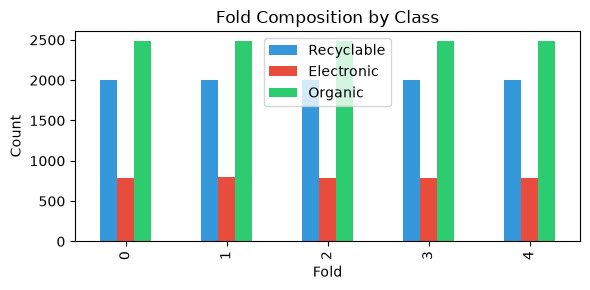


train_master_with_folds.csv saved -> /workspace/satria-data-bdc/outputs


In [7]:
# Cell 6 - StratifiedGroupKFold 5-Fold Split
# Assigns stratified group-aware folds and saves the final manifest.

cv_pool = train_master[
    (~train_master["exclude_from_cv"]) &
    (~train_master["exclude_from_training"])
].reset_index(drop=True).copy()

print(f"CV pool size         : {len(cv_pool):,}  (expected ~{EXPECTED_CV_POOL_SIZE})")
print(f"Unique groups in pool: {cv_pool['duplicate_group_id'].nunique():,}")

sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

cv_pool["fold"] = -1
X      = cv_pool["filename"]
y      = cv_pool["label"]
groups = cv_pool["duplicate_group_id"]

for fold_idx, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups)):
    cv_pool.loc[val_idx, "fold"] = fold_idx

assert (cv_pool["fold"] == -1).sum() == 0, \
    "Some rows were not assigned a fold - check StratifiedGroupKFold logic"

group_fold_check = cv_pool.groupby("duplicate_group_id")["fold"].nunique()
leaky_groups     = group_fold_check[group_fold_check > 1]
assert len(leaky_groups) == 0, \
    f"GROUP LEAKAGE: {len(leaky_groups)} groups span multiple folds!"
print("Group integrity check : PASSED (no group spans multiple folds)")

balance = (
    cv_pool.groupby("fold")["label"]
    .value_counts(normalize=True)
    .unstack()
    .rename(columns={0: "Recyclable", 1: "Electronic", 2: "Organic"})
    .round(4)
)
global_ratio = cv_pool["label"].value_counts(normalize=True).sort_index()
global_ratio.index = ["Recyclable", "Electronic", "Organic"]
deviation = (balance - global_ratio).abs()
max_dev   = deviation.values.max()

print("\nClass balance per fold:")
print(balance.to_string())
print(f"\nMax deviation from global ratio: {max_dev:.4f}  ", end="")
print("OK (<0.02)" if max_dev < 0.02 else "WARNING (>0.02)")

print("\nFold sizes:")
print(cv_pool["fold"].value_counts().sort_index().to_string())

fold_signature = hashlib.md5(
    cv_pool[["filename", "fold"]].to_csv(index=False).encode()
).hexdigest()
print(f"\nFold signature (MD5): {fold_signature}")

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
fold_class_counts = cv_pool.groupby(["fold", "label"]).size().unstack()
fold_class_counts.columns = ["Recyclable", "Electronic", "Organic"]
fold_class_counts.plot(kind="bar", stacked=False, ax=ax, color=["#3498db", "#e74c3c", "#2ecc71"])
ax.set_title("Fold Composition by Class")
ax.set_xlabel("Fold")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

fold_map = dict(zip(cv_pool["filename"], cv_pool["fold"]))
train_master["fold"] = train_master["filename"].map(fold_map).fillna(-1).astype(int)

train_master.to_csv(OUTPUT_DIR / "train_master_with_folds.csv", index=False)
print(f"\ntrain_master_with_folds.csv saved -> {OUTPUT_DIR}")

In [8]:
# Cell 7 - Integrity Assertions
# Pre-training automated sanity checks to guarantee pipeline safety.
assert len(train_master) == EXPECTED_TRAIN_COUNT, f"Row count changed! Expected {EXPECTED_TRAIN_COUNT}, got {len(train_master)}"

assert train_master["filename"].duplicated().sum() == 0, "Duplicate filenames detected in master!"

assert train_master["exclude_from_cv"].sum() == EXPECTED_CV_EXCLUDE, "Overlap exclusion count mismatch!"
assert train_master["exclude_from_training"].sum() == EXPECTED_TRAINING_EXCLUDE, "Training exclusion count mismatch!"

assert train_master[(~train_master["exclude_from_cv"]) & (~train_master["exclude_from_training"])]["fold"].min() >= 0, "Some eligible rows missed fold assignment!"

eligible = train_master[~train_master["exclude_from_training"]]
missing = eligible[~eligible["filepath"].apply(lambda p: Path(p).exists())]
assert len(missing) == 0, f"{len(missing)} eligible files missing from disk!"

random.seed(SEED)
spot_check_files = random.sample(
    train_master[~train_master["exclude_from_training"]]["filepath"].tolist(), 50
)
load_errors = []
for fp in spot_check_files:
    try:
        with Image.open(fp) as img:
            img.verify()
    except Exception as e:
        load_errors.append((fp, str(e)))
assert len(load_errors) == 0, f"Corrupt images detected: {load_errors[:5]}"
print("Spot-check: 50 random images loaded successfully.")

print("\nALL DATA PIPELINE ASSERTIONS PASSED.")
print("The dataset is clean, split, and ready for training.\n")

Spot-check: 50 random images loaded successfully.

ALL DATA PIPELINE ASSERTIONS PASSED.
The dataset is clean, split, and ready for training.



In [9]:
# Cell 8 - Test Set Loader Setup
submission_path = DATA_DIR / "submission.csv"
submission_df   = pd.read_csv(submission_path)
print(f"Loaded submission.csv - {len(submission_df)} rows")
assert list(submission_df.columns) == ["id", "predicted"], "submission.csv columns malformed!"
print(submission_df.dtypes)

missing_files = []
test_files_ordered = []
for row in submission_df.itertuples(index=False):
    img_id   = int(row.id)
    img_path = TEST_DIR / f"{img_id}.jpg"

    if not img_path.exists():
        missing_files.append(img_path)
    else:
        test_files_ordered.append(str(img_path))

assert len(missing_files) == 0, f"Missing {len(missing_files)} test files! First 5: {missing_files[:5]}"
submission_df["filepath"] = test_files_ordered

test_dimensions = set()
for fp in test_files_ordered[:100]:
    with Image.open(fp) as img:
        test_dimensions.add(img.size)
print(f"Test image dimensions (sample of 100): {test_dimensions}")
if len(test_dimensions) > 1:
    print("WARNING: Test images have varying dimensions - resize transform must handle this.")
print(f"All {len(test_files_ordered)} test files found on disk.")
print("Test paths aligned with submission.csv order.")

Loaded submission.csv - 1458 rows
id             int64
predicted    float64
dtype: object
Test image dimensions (sample of 100): {(260, 194), (215, 235), (3456, 4608), (297, 170), (204, 247), (255, 198), (1280, 720), (286, 176), (277, 182), (224, 225), (201, 251), (203, 248), (200, 200), (357, 141), (301, 167), (320, 180), (276, 183), (308, 163), (249, 202), (150, 150), (199, 253), (183, 275), (300, 168), (800, 573), (259, 194), (211, 239), (320, 158), (205, 205), (197, 255), (365, 138), (252, 200), (224, 224), (189, 266), (276, 182), (278, 182), (284, 177), (219, 230), (225, 225), (262, 192), (275, 183), (245, 206), (291, 173), (290, 174), (261, 193), (358, 141), (226, 223)}
All 1458 test files found on disk.
Test paths aligned with submission.csv order.


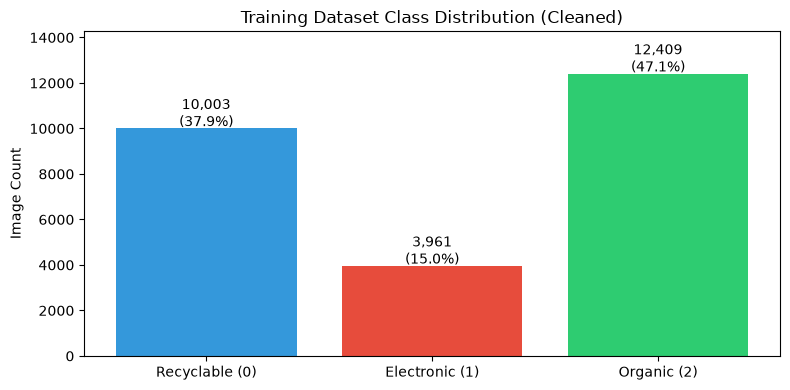

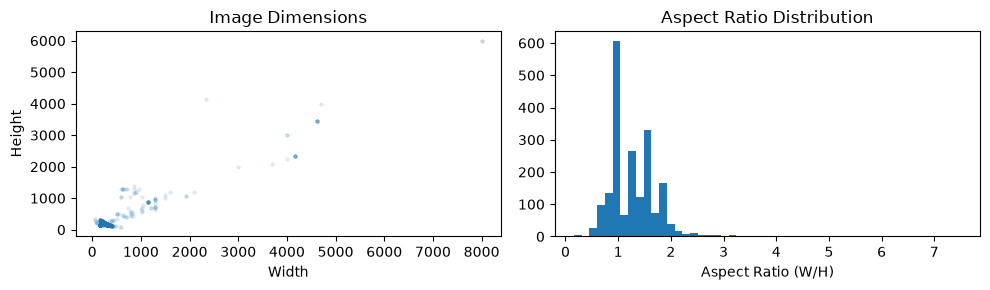

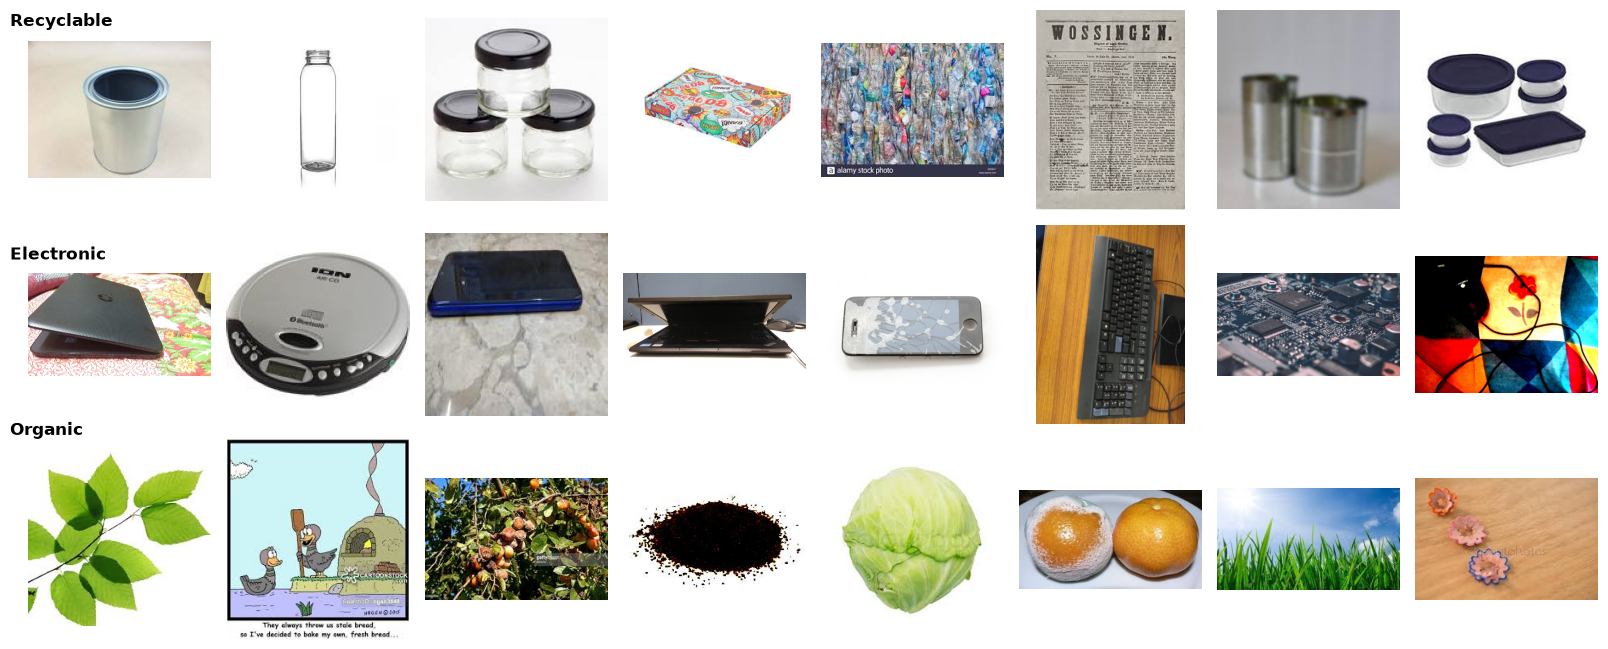

In [10]:
# Cell 9 - Class Distribution and Sample Grid
# Visualizes class distribution and displays a sample grid of images.
valid_train = train_master[
    (~train_master["exclude_from_cv"]) & 
    (~train_master["exclude_from_training"])
]

plt.figure(figsize=(8, 4))
dist = valid_train["label"].value_counts().sort_index()
bars = plt.bar(["Recyclable (0)", "Electronic (1)", "Organic (2)"], dist.values, color=["#3498db", "#e74c3c", "#2ecc71"])

plt.title("Training Dataset Class Distribution (Cleaned)")
plt.ylabel("Image Count")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, f"{yval:,}\n({yval/len(valid_train):.1%})", ha="center")
plt.ylim(0, max(dist.values) * 1.15)
plt.tight_layout()
plt.show()

dims = []
for fp in valid_train["filepath"].sample(min(2000, len(valid_train)), random_state=SEED):
    try:
        with Image.open(fp) as img:
            dims.append(img.size)
    except:
        pass
dim_df = pd.DataFrame(dims, columns=["width", "height"])
dim_df["aspect_ratio"] = dim_df["width"] / dim_df["height"]

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].scatter(dim_df["width"], dim_df["height"], alpha=0.1, s=5)
axes[0].set_xlabel("Width")
axes[0].set_ylabel("Height")
axes[0].set_title("Image Dimensions")
axes[1].hist(dim_df["aspect_ratio"], bins=50)
axes[1].set_xlabel("Aspect Ratio (W/H)")
axes[1].set_title("Aspect Ratio Distribution")
plt.tight_layout()
plt.show()

random.seed(SEED)
n_per_class = 8
fig, axes   = plt.subplots(3, n_per_class, figsize=(n_per_class * 2, 6.6))

for row_idx, label_id in enumerate([0, 1, 2]):
    subset = valid_train[valid_train["label"] == label_id]["filepath"].tolist()
    samples = random.sample(subset, n_per_class)
    
    for col_idx, fpath in enumerate(samples):
        ax = axes[row_idx, col_idx]
        try:
            img = Image.open(fpath).convert("RGB")
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, "Load Error", ha="center")
        ax.axis("off")
        
    class_name = LABEL_MAP[label_id]
    axes[row_idx, 0].set_title(class_name, loc="left", fontsize=12, fontweight="bold", x=-0.1, y=1.05)

plt.tight_layout()
plt.show()

Electronic Class Sub-populations (Total scanned: 3961):
  - 150x150 Icons : 2657 (67.1%)
  - Natural Photos: 1304 (32.9%)


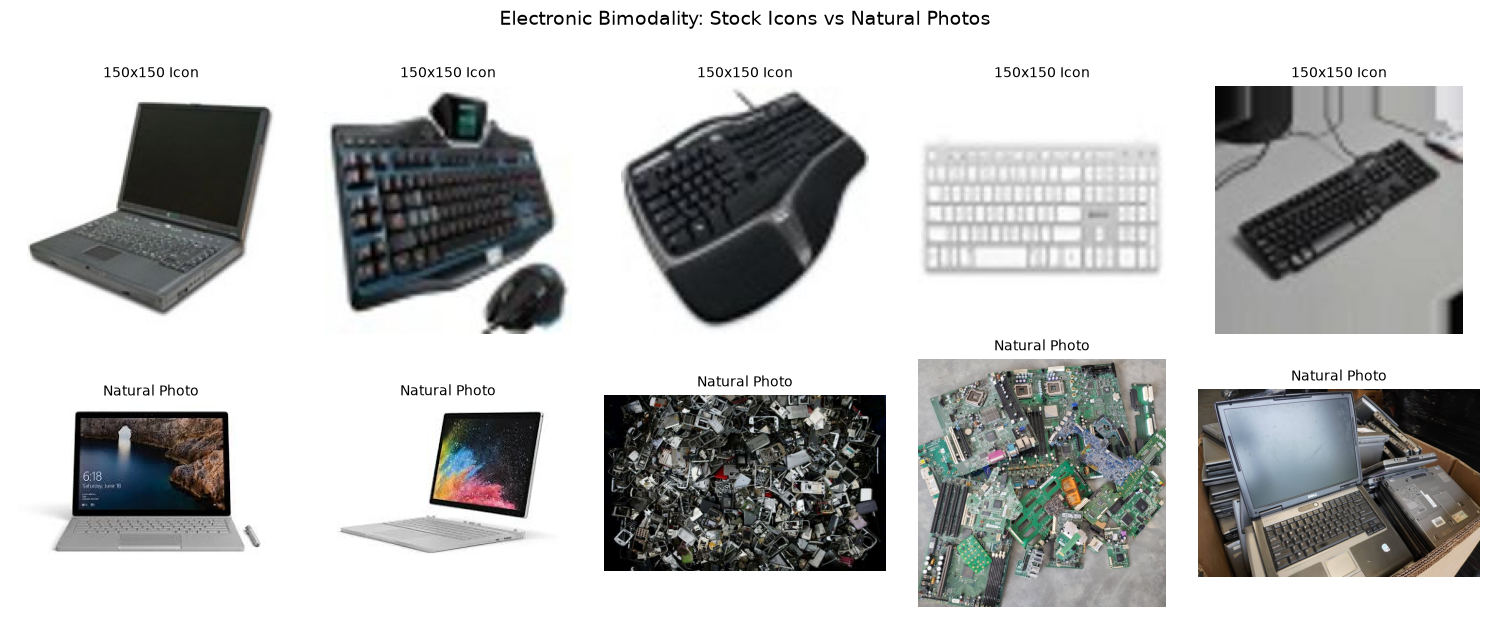


Color mode distribution (sample of 2000):
RGB     1980
P         19
RGBA       1



In [11]:
# Cell 10 - Electronic Bimodal Analysis
# Visualizes the two Electronic sub-populations (150x150 icons vs natural photos).
electronic_files = valid_train[valid_train["label"] == 1]["filepath"].tolist()

n_icon_150 = 0
n_natural  = 0
icon_samples = []
natural_samples = []

for fp in electronic_files:
    try:
        with Image.open(fp) as img:
            w, h = img.size
            if w == 150 and h == 150:
                n_icon_150 += 1
                if len(icon_samples) < 5:
                    icon_samples.append(fp)
            else:
                n_natural += 1
                if len(natural_samples) < 5:
                    natural_samples.append(fp)
    except Exception:
        pass

total_elec = n_icon_150 + n_natural
print(f"Electronic Class Sub-populations (Total scanned: {total_elec}):")
print(f"  - 150x150 Icons : {n_icon_150} ({n_icon_150/total_elec:.1%})")
print(f"  - Natural Photos: {n_natural} ({n_natural/total_elec:.1%})")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, f in enumerate(icon_samples):
    axes[0, i].imshow(Image.open(f).convert("RGB"))
    axes[0, i].set_title(f"150x150 Icon", fontsize=10)
    axes[0, i].axis("off")

for i, f in enumerate(natural_samples):
    axes[1, i].imshow(Image.open(f).convert("RGB"))
    axes[1, i].set_title(f"Natural Photo", fontsize=10)
    axes[1, i].axis("off")

plt.suptitle("Electronic Bimodality: Stock Icons vs Natural Photos", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

color_modes = []
for fp in valid_train["filepath"].sample(min(2000, len(valid_train)), random_state=SEED):
    try:
        with Image.open(fp) as img:
            color_modes.append(img.mode)
    except:
        pass

mode_counts = pd.Series(color_modes).value_counts()
print("\nColor mode distribution (sample of 2000):")
print(mode_counts.to_string())

non_rgb = mode_counts.drop("RGB", errors="ignore").sum()
if non_rgb > 0:
    print(f"\nWARNING: {non_rgb} non-RGB images found. Transform must convert to RGB.")

In [12]:
# Cell 11 - Image Quality and Format Analysis
# Analyzes file sizes, validates extensions, and scans for truncated/corrupt images.
file_sizes = []
extensions = set()
truncated_files = []

for fp in valid_train["filepath"]:
    try:
        ext = Path(fp).suffix.lower()
        extensions.add(ext)
        size = os.path.getsize(fp)
        file_sizes.append({"filepath": fp, "size_kb": size / 1024, "label": train_master[train_master["filepath"] == fp]["label"].values[0]})
        
        with Image.open(fp) as img:
            img.load()
    except Exception as e:
        truncated_files.append({"filepath": fp, "error": str(e)})

print(f"Extensions found: {extensions}")
assert extensions.issubset({".jpg", ".jpeg", ".png"}), "Unexpected file extension detected!"

size_df = pd.DataFrame(file_sizes)
print("\nFile size statistics (KB) per class:")
print(size_df.groupby("label")["size_kb"].describe().to_string())

if truncated_files:
    print(f"\nWARNING: Found {len(truncated_files)} truncated/corrupt images:")
    for t in truncated_files[:5]:
        print(f"  {t['filepath']} - {t['error']}")
else:
    print("\nNo truncated or corrupt images detected.")

Extensions found: {'.jpeg', '.png', '.jpg'}

File size statistics (KB) per class:
         count        mean          std       min       25%       50%        75%           max
label                                                                                         
0      10003.0    7.431829     4.440847  0.771484  4.077148  6.301758   9.875977     32.283203
1       3961.0  270.090642  1195.539266  1.275391  3.291016  4.552734  49.916016  19262.674805
2      12409.0    9.698724     4.245957  1.322266  6.563477  9.080078  12.060547     36.151367

No truncated or corrupt images detected.


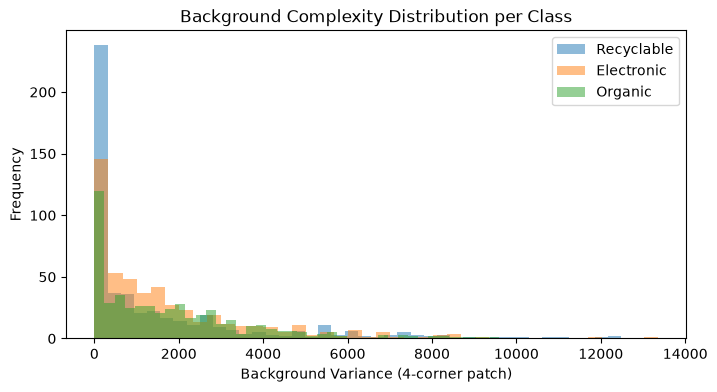

Proportion of plain-background images (variance < 50):
class
Electronic    15.4%
Organic       17.0%
Recyclable    36.0%
Name: is_plain_bg, dtype: str

Risk Flagged: Recyclable has a high rate of plain backgrounds.
Action: We will run Grad-CAM post-training to verify the model didn't learn this shortcut.


In [13]:
# Cell 12 - Shortcut Risk Analysis
# Analyzes background complexity to assess if the model might learn a background shortcut.
def compute_background_complexity(img_path, patch_size=30):
    try:
        img = Image.open(img_path).convert("RGB")
        arr = np.array(img)
        h, w, _ = arr.shape
        p = patch_size
        
        corners = [
            arr[0:p, 0:p],
            arr[0:p, w-p:w],
            arr[h-p:h, 0:p],
            arr[h-p:h, w-p:w]
        ]
        return np.mean([c.var() for c in corners])
    except Exception:
        return np.nan

random.seed(SEED)
bg_results = []
for label_id in [0, 1, 2]:
    subset = valid_train[valid_train["label"] == label_id]["filepath"].tolist()
    samples = random.sample(subset, min(500, len(subset)))
    for fp in samples:
        bg_results.append({
            "class": LABEL_MAP[label_id],
            "bg_variance": compute_background_complexity(fp)
        })

df_bg = pd.DataFrame(bg_results).dropna()

plt.figure(figsize=(8, 4))
for cls_name in ["Recyclable", "Electronic", "Organic"]:
    subset = df_bg[df_bg["class"] == cls_name]["bg_variance"]
    plt.hist(subset, bins=40, alpha=0.5, label=cls_name)

plt.xlabel("Background Variance (4-corner patch)")
plt.ylabel("Frequency")
plt.title("Background Complexity Distribution per Class")
plt.legend()
plt.show()

threshold = 50
df_bg["is_plain_bg"] = df_bg["bg_variance"] < threshold
print("Proportion of plain-background images (variance < 50):")
print(df_bg.groupby("class")["is_plain_bg"].mean().apply(lambda x: f"{x:.1%}"))
print("\nRisk Flagged: Recyclable has a high rate of plain backgrounds.")
print("Action: We will run Grad-CAM post-training to verify the model didn't learn this shortcut.")

In [ ]:
# Cell 13 - Transforms and Dataset

IMAGENET_MEAN_RGB = (int(0.485 * 255), int(0.456 * 255), int(0.406 * 255))

def get_transforms(img_size):
    train_tfm = T.Compose([
        T.Resize((img_size, img_size), interpolation=InterpolationMode.BICUBIC),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomVerticalFlip(p=0.5),  
        T.RandomRotation(degrees=(0, 180), fill=IMAGENET_MEAN_RGB), 
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    eval_tfm = T.Compose([
        T.Resize((img_size, img_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return train_tfm, eval_tfm

def load_image_as_rgb(path, fallback_size=384):
    try:
        return Image.open(path).convert("RGB")
    except Exception as e:
        logger.error(f"Failed to load {path}: {e}")
        return Image.new("RGB", (fallback_size, fallback_size), (0, 0, 0))

class WasteDataset(Dataset):
    def __init__(self, df, transform=None, is_test=False, img_size=384):
        self.df = df
        self.transform = transform
        self.is_test = is_test
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        filepath = self.df.iloc[idx]["filepath"]
        try:
            image = load_image_as_rgb(filepath, fallback_size=self.img_size)
            if self.transform:
                image = self.transform(image)
            if self.is_test:
                return image, idx
            label = self.df.iloc[idx]["label"]
            return image, label
        except Exception as e:
            logger.error(f"Dataset error at idx={idx}, file={filepath}: {e}")
            image = torch.zeros(3, self.img_size, self.img_size)
            if self.is_test: return image, idx
            return image, self.df.iloc[idx]["label"]

In [ ]:
# Cell 14 - Model Builder, Optimizer, Scheduler, and Training Utilities

def build_model(model_name, pretrained=True, img_size=None):
    kwargs = {
        "pretrained": pretrained,
        "num_classes": 3
    }
    
    # Only pass img_size for Vision Transformers to avoid breaking CNN kwargs
    if img_size is not None and "vit" in model_name.lower():
        kwargs["img_size"] = img_size
        
    model = timm.create_model(model_name, **kwargs)
    return model

def get_optimizer(model, backbone_lr, head_lr):
    backbone_params, head_params = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad: continue
        if "head" in name: head_params.append(param)
        else: backbone_params.append(param)
            
    optimizer = torch.optim.AdamW([
        {"params": backbone_params, "lr": backbone_lr},
        {"params": head_params,     "lr": head_lr}
    ], weight_decay=WEIGHT_DECAY)
    
    return optimizer, len(backbone_params), len(head_params)

def get_scheduler(optimizer, steps_per_epoch, num_epochs, warmup_ratio=WARMUP_STEPS_RATIO):
    total_steps = steps_per_epoch * num_epochs
    warmup_steps = int(total_steps * warmup_ratio)
    
    def lr_lambda(current_step):
        if current_step < warmup_steps:
            return float(current_step) / float(max(1, warmup_steps))
        progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
        
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def update_ema(model, ema_model, decay=EMA_DECAY_CNN):
    with torch.no_grad():
        for ema_param, model_param in zip(ema_model.parameters(), model.parameters()):
            ema_param.data.mul_(decay).add_(model_param.data, alpha=1 - decay)

def train_one_epoch(model, ema_model, dataloader, criterion, optimizer, scheduler, scaler, ema_decay):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []
    total_grad_norm = 0.0
    valid_batches = 0
    
    pbar = tqdm(dataloader, desc="Train Epoch", leave=False)
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)
            
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        
        scaler.unscale_(optimizer)
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()
        
        if torch.isfinite(grad_norm):
            total_grad_norm += grad_norm.item()
            valid_batches += 1
            scheduler.step()
            update_ema(model, ema_model, decay=ema_decay)
            pbar.set_postfix({"loss": f"{loss.item():.4f}", "lr": f"{optimizer.param_groups[0]['lr']:.1e}"})
        else:
            pbar.set_postfix({"status": "SKIPPED EMA/Sched (inf grad)"})
        
        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_macro_f1 = f1_score(all_labels, all_preds, average="macro")
    avg_grad_norm = total_grad_norm / max(1, valid_batches)
    
    return {
        "loss": epoch_loss, 
        "macro_f1": epoch_macro_f1, 
        "grad_norm": avg_grad_norm
    }

@torch.no_grad()
def validate_epoch(ema_model, dataloader, criterion):
    ema_model.eval()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    
    for images, labels in dataloader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        with torch.amp.autocast('cuda'):
            outputs = ema_model(images)
            loss = criterion(outputs, labels)
            
        running_loss += loss.item() * images.size(0)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
    epoch_loss = running_loss / len(dataloader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    f1_per_class = f1_score(all_labels, all_preds, average=None)
    precision_per_class = precision_score(all_labels, all_preds, average=None, zero_division=0)
    recall_per_class = recall_score(all_labels, all_preds, average=None, zero_division=0)
    
    return {
        "loss": epoch_loss, 
        "macro_f1": macro_f1, 
        "f1_per_class": f1_per_class,
        "precision_per_class": precision_per_class,
        "recall_per_class": recall_per_class,
        "probs": np.array(all_probs),
        "preds": np.array(all_preds),
        "labels": np.array(all_labels)
    }

In [16]:
# Cell 15 - Training Utilities
# Core functions for training and validation.

def update_ema(model, ema_model, decay=EMA_DECAY_CNN):
    with torch.no_grad():
        for ema_param, model_param in zip(ema_model.parameters(), model.parameters()):
            ema_param.data.mul_(decay).add_(model_param.data, alpha=1 - decay)

def train_one_epoch(model, ema_model, dataloader, criterion, optimizer, scheduler, scaler, ema_decay):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []
    total_grad_norm = 0.0
    
    pbar = tqdm(dataloader, desc="Train Epoch", leave=False)
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)
            
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        
        scaler.unscale_(optimizer)
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_NORM)
        total_grad_norm += grad_norm.item()
        
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        update_ema(model, ema_model, decay=ema_decay)
        
        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        pbar.set_postfix({"loss": f"{loss.item():.4f}", "lr": f"{optimizer.param_groups[0]['lr']:.1e}"})
        
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_macro_f1 = f1_score(all_labels, all_preds, average="macro")
    avg_grad_norm = total_grad_norm / len(dataloader)
    
    return {
        "loss": epoch_loss, 
        "macro_f1": epoch_macro_f1, 
        "grad_norm": avg_grad_norm
    }

@torch.no_grad()
def validate_epoch(ema_model, dataloader, criterion):
    ema_model.eval()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    
    for images, labels in dataloader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        with torch.amp.autocast('cuda'):
            outputs = ema_model(images)
            loss = criterion(outputs, labels)
            
        running_loss += loss.item() * images.size(0)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
    epoch_loss = running_loss / len(dataloader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    f1_per_class = f1_score(all_labels, all_preds, average=None)
    precision_per_class = precision_score(all_labels, all_preds, average=None, zero_division=0)
    recall_per_class = recall_score(all_labels, all_preds, average=None, zero_division=0)
    
    return {
        "loss": epoch_loss, 
        "macro_f1": macro_f1, 
        "f1_per_class": f1_per_class,
        "precision_per_class": precision_per_class,
        "recall_per_class": recall_per_class,
        "probs": np.array(all_probs),
        "preds": np.array(all_preds),
        "labels": np.array(all_labels)
    }

In [17]:
# Cell 16 - 5-Fold Training Runner
# Generalized 5-Fold Training Runner with OOF tracking, resumability, and periodic checkpointing.

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

def run_5fold_training(model_name, img_size, prefix, batch_size, backbone_lr, head_lr, ema_decay):
    print(f"\nSTARTING TRAINING: {prefix} ({model_name} @ {img_size}px)\n")
    
    train_tfm, eval_tfm = get_transforms(img_size)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    
    oof_probs  = np.zeros((len(train_master), 3), dtype=np.float32)
    oof_labels = np.full((len(train_master)), -1, dtype=int)
    
    fold_results = {}
    progress_file = OUTPUT_DIR / f"{prefix}_kfold_progress.json"
    completed_folds = []
    
    if progress_file.exists():
        with open(progress_file, "r") as f:
            completed_folds = json.load(f)
        print(f"Resuming {prefix}: Folds {completed_folds} already completed.")
        
    for fold in range(N_SPLITS):
        if fold in completed_folds:
            print(f"Fold {fold} already completed. Restoring data from checkpoint...")
            checkpoint_path = OUTPUT_DIR / f"{prefix}_fold{fold}_best.pt"
            if not checkpoint_path.exists():
                raise FileNotFoundError(f"Missing checkpoint: {checkpoint_path}")
                
            ckpt = torch.load(checkpoint_path, map_location="cpu")
            oof_probs[ckpt["val_indices"]] = ckpt["best_probs"]
            oof_labels[ckpt["val_indices"]] = ckpt["best_labels"]
            
            fold_results[fold] = {
                "best_f1": ckpt["best_f1"],
                "best_per_class_f1": ckpt["best_per_class_f1"],
                "history": ckpt["history"]
            }
            continue
            
        print(f"\n--- FOLD {fold+1}/{N_SPLITS} ---")
        
        train_df = train_master[
            (train_master["fold"] != fold) & 
            (~train_master["exclude_from_training"])
        ].copy()
        val_df = train_master[
            (train_master["fold"] == fold) & 
            (~train_master["exclude_from_training"])
        ].copy()
        
        train_ds = WasteDataset(train_df, transform=train_tfm, img_size=img_size)
        val_ds   = WasteDataset(val_df, transform=eval_tfm, img_size=img_size)
        
        train_loader = DataLoader(
            train_ds, batch_size=batch_size, shuffle=True, 
            num_workers=NUM_WORKERS, pin_memory=True, drop_last=True, 
            persistent_workers=True, worker_init_fn=seed_worker, generator=g
        )
        val_loader = DataLoader(
            val_ds, batch_size=batch_size, shuffle=False, 
            num_workers=NUM_WORKERS, pin_memory=True, 
            persistent_workers=True, worker_init_fn=seed_worker, generator=g
        )
        
        model = build_model(model_name, pretrained=True, img_size=img_size).to(DEVICE)
        ema_model = copy.deepcopy(model).eval().to(DEVICE)
        optimizer, _, _ = get_optimizer(model, backbone_lr, head_lr)
        scheduler = get_scheduler(optimizer, len(train_loader), NUM_EPOCHS)
        scaler = torch.amp.GradScaler('cuda')
        
        best_f1 = 0.0
        best_per_class_f1 = None
        best_probs = None
        best_preds = None
        best_labels = None
        history = defaultdict(list)
        early_stop_counter = 0
        
        for epoch in range(NUM_EPOCHS):
            start_time = time.time()
            
            train_res = train_one_epoch(model, ema_model, train_loader, criterion, optimizer, scheduler, scaler, ema_decay)
            val_res   = validate_epoch(ema_model, val_loader, criterion)
            
            elapsed = time.time() - start_time
            
            history["train_loss"].append(train_res["loss"])
            history["val_loss"].append(val_res["loss"])
            history["val_macro_f1"].append(val_res["macro_f1"])
            
            lr_back = optimizer.param_groups[0]['lr']
            per_class_str = " | ".join([
                f"{LABEL_MAP[i][:3]}: {val_res['f1_per_class'][i]:.3f}"
                for i in range(3)
            ])
            print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | {elapsed:.0f}s | LR: {lr_back:.1e} | "
                  f"Train Loss: {train_res['loss']:.4f} | Val Loss: {val_res['loss']:.4f} | "
                  f"Val Macro F1: {val_res['macro_f1']:.4f}")
            print(f"  Per-class F1: {per_class_str} | Grad norm: {train_res['grad_norm']:.2f}")
            
            if val_res["macro_f1"] > best_f1 + EARLY_STOPPING_MIN_DELTA:
                early_stop_counter = 0
                best_f1 = val_res["macro_f1"]
                best_per_class_f1 = val_res["f1_per_class"]
                best_probs  = val_res["probs"]
                best_preds  = val_res["preds"]
                best_labels = val_res["labels"]
                
                checkpoint_path = OUTPUT_DIR / f"{prefix}_fold{fold}_best.pt"
                torch.save({
                    "epoch": epoch + 1,
                    "model_state_dict": ema_model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_f1": best_f1,
                    "run_id": RUN_ID,
                    "best_probs": best_probs,
                    "best_labels": best_labels,
                    "val_indices": val_df.index.to_numpy(),
                    "best_per_class_f1": best_per_class_f1,
                    "history": dict(history)
                }, checkpoint_path)
                print(f"  -> Best model saved! (Macro F1: {best_f1:.4f})")
            else:
                early_stop_counter += 1
                if early_stop_counter >= EARLY_STOPPING_PATIENCE:
                    print(f"  Early stopping triggered at epoch {epoch+1} (patience={EARLY_STOPPING_PATIENCE})")
                    break
                    
            if SAVE_PERIODIC_CHECKPOINTS and (epoch + 1) % CHECKPOINT_EVERY_N_EPOCHS == 0:
                periodic_path = OUTPUT_DIR / f"{prefix}_fold{fold}_epoch{epoch+1}.pt"
                torch.save({
                    "epoch": epoch + 1,
                    "model_state_dict": ema_model.state_dict(),
                    "best_f1": best_f1,
                    "run_id": RUN_ID,
                }, periodic_path)
                
        fold_results[fold] = {
            "best_f1": best_f1,
            "history": dict(history),
            "best_per_class_f1": best_per_class_f1
        }
        
        val_indices = val_df.index
        oof_probs[val_indices] = best_probs
        oof_labels[val_indices] = best_labels
        
        completed_folds.append(fold)
        tmp_fd, tmp_path = tempfile.mkstemp(dir=OUTPUT_DIR)
        with os.fdopen(tmp_fd, "w") as f:
            json.dump(completed_folds, f)
        os.replace(tmp_path, progress_file)
        
        del model, ema_model, optimizer, scheduler, scaler
        del train_loader, val_loader, train_ds, val_ds
        torch.cuda.empty_cache()
        
    mean_cv = np.mean([fold_results[f]['best_f1'] for f in range(N_SPLITS)])
    print(f"\n{prefix.upper()} TRAINING COMPLETE.")
    print(f"5-Fold CV Score: {mean_cv:.4f}\n")
    
    return fold_results, oof_probs, oof_labels

In [ ]:
# Cell 17 - EXECUTION: ConvNeXt Training
# Train ConvNeXt V2 (384px)
convnext_fold_results, convnext_oof_probs, convnext_oof_labels = run_5fold_training(
    model_name=MODEL_NAME_CNN, 
    img_size=IMG_SIZE_CNN, 
    prefix="convnext", 
    batch_size=BATCH_SIZE_CNN, 
    backbone_lr=BACKBONE_LR_CNN, 
    head_lr=HEAD_LR, 
    ema_decay=EMA_DECAY_CNN
)


STARTING TRAINING: convnext (convnextv2_tiny.fcmae_ft_in22k_in1k @ 384px)


--- FOLD 1/5 ---


2026-07-27 11:09:46,021 [INFO] Loading pretrained weights from Hugging Face hub (timm/convnextv2_tiny.fcmae_ft_in22k_in1k)
2026-07-27 11:09:46,387 [INFO] HTTP Request: HEAD https://huggingface.co/timm/convnextv2_tiny.fcmae_ft_in22k_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
2026-07-27 11:09:46,387 [WARNING] Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-07-27 11:09:46,388 [INFO] [timm/convnextv2_tiny.fcmae_ft_in22k_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
2026-07-27 11:09:46,400 [INFO] Missing keys (head.fc.weight, head.fc.bias) discovered while loading pretrained weights. This is expected if model is being adapted.


Train Epoch:   0%|          | 0/662 [00:00<?, ?it/s]

Epoch 01/40 | 185s | LR: 3.3e-06 | Train Loss: 0.7961 | Val Loss: 0.9858 | Val Macro F1: 0.5024
  Per-class F1: Rec: 0.567 | Ele: 0.374 | Org: 0.567 | Grad norm: inf
  -> Best model saved! (Macro F1: 0.5024)


Train Epoch:   0%|          | 0/662 [00:00<?, ?it/s]

...

Train Epoch:   0%|          | 0/662 [00:00<?, ?it/s]

Epoch 19/40 | 178s | LR: 6.1e-06 | Train Loss: 0.2940 | Val Loss: 0.3275 | Val Macro F1: 0.9849
  Per-class F1: Rec: 0.978 | Ele: 0.994 | Org: 0.982 | Grad norm: 1.35


Train Epoch:   0%|          | 0/662 [00:00<?, ?it/s]

Epoch 20/40 | 178s | LR: 5.6e-06 | Train Loss: 0.2940 | Val Loss: 0.3283 | Val Macro F1: 0.9851
  Per-class F1: Rec: 0.978 | Ele: 0.994 | Org: 0.983 | Grad norm: 1.26


Train Epoch:   0%|          | 0/662 [00:00<?, ?it/s]

In [19]:
# Cell 18 - EXECUTION: DINOv2 Training
# Train DINOv2 (518px) with lower LR to prevent catastrophic forgetting
dinov2_fold_results, dinov2_oof_probs, dinov2_oof_labels = run_5fold_training(
    model_name=MODEL_NAME_VIT, 
    img_size=IMG_SIZE_VIT, 
    prefix="dinov2", 
    batch_size=BATCH_SIZE_VIT, 
    backbone_lr=BACKBONE_LR_VIT, 
    head_lr=HEAD_LR, 
    ema_decay=EMA_DECAY_VIT
)

Epoch 01/40 | 154s | LR: 1.7e-06 | Train Loss: 0.5739 | Val Loss: 0.8149 | Val Macro F1: 0.6583
  Per-class F1: Rec: 0.666 | Ele: 0.540 | Org: 0.768 | Grad norm: inf
  -> Best model saved! (Macro F1: 0.6583)


Train Epoch:   0%|          | 0/1324 [00:00<?, ?it/s]

Epoch 02/40 | 154s | LR: 3.3e-06 | Train Loss: 0.3998 | Val Loss: 0.4742 | Val Macro F1: 0.9243
  Per-class F1: Rec: 0.913 | Ele: 0.921 | Org: 0.938 | Grad norm: 63.02
  -> Best model saved! (Macro F1: 0.9243)


Train Epoch:   0%|          | 0/1324 [00:00<?, ?it/s]

Epoch 03/40 | 154s | LR: 5.0e-06 | Train Loss: 0.3882 | Val Loss: 0.3826 | Val Macro F1: 0.9589
  Per-class F1: Rec: 0.947 | Ele: 0.968 | Org: 0.962 | Grad norm: inf
  -> Best model saved! (Macro F1: 0.9589)


...

Epoch 14/40 | 154s | LR: 4.0e-06 | Train Loss: 0.3267 | Val Loss: 0.3425 | Val Macro F1: 0.9806
  Per-class F1: Rec: 0.973 | Ele: 0.989 | Org: 0.980 | Grad norm: 31.79


Train Epoch:   0%|          | 0/1324 [00:00<?, ?it/s]

Epoch 15/40 | 154s | LR: 3.8e-06 | Train Loss: 0.3229 | Val Loss: 0.3414 | Val Macro F1: 0.9806
  Per-class F1: Rec: 0.973 | Ele: 0.989 | Org: 0.980 | Grad norm: inf


Train Epoch:   0%|          | 0/1324 [00:00<?, ?it/s]

Epoch 16/40 | 154s | LR: 3.6e-06 | Train Loss: 0.3176 | Val Loss: 0.3431 | Val Macro F1: 0.9812
  Per-class F1: Rec: 0.973 | Ele: 0.991 | Org: 0.980 | Grad norm: inf
  Early stopping triggered at epoch 16 (patience=7)

DINOV2 TRAINING COMPLETE.
5-Fold CV Score: 0.9799



CONVNEXT V2 DIAGNOSTICS
Final 5-Fold CV Score (ConvNeXt V2): 0.9839 +/- 0.0017

Per-Fold Per-Class F1:
Fold   Recyclable   Electronic   Organic      Macro   
----------------------------------------------------
0      0.9724       0.9918       0.9785       0.9809  
1      0.9757       0.9937       0.9813       0.9836  
2      0.9760       0.9943       0.9820       0.9841  
3      0.9793       0.9943       0.9843       0.9860  
4      0.9788       0.9924       0.9833       0.9848  


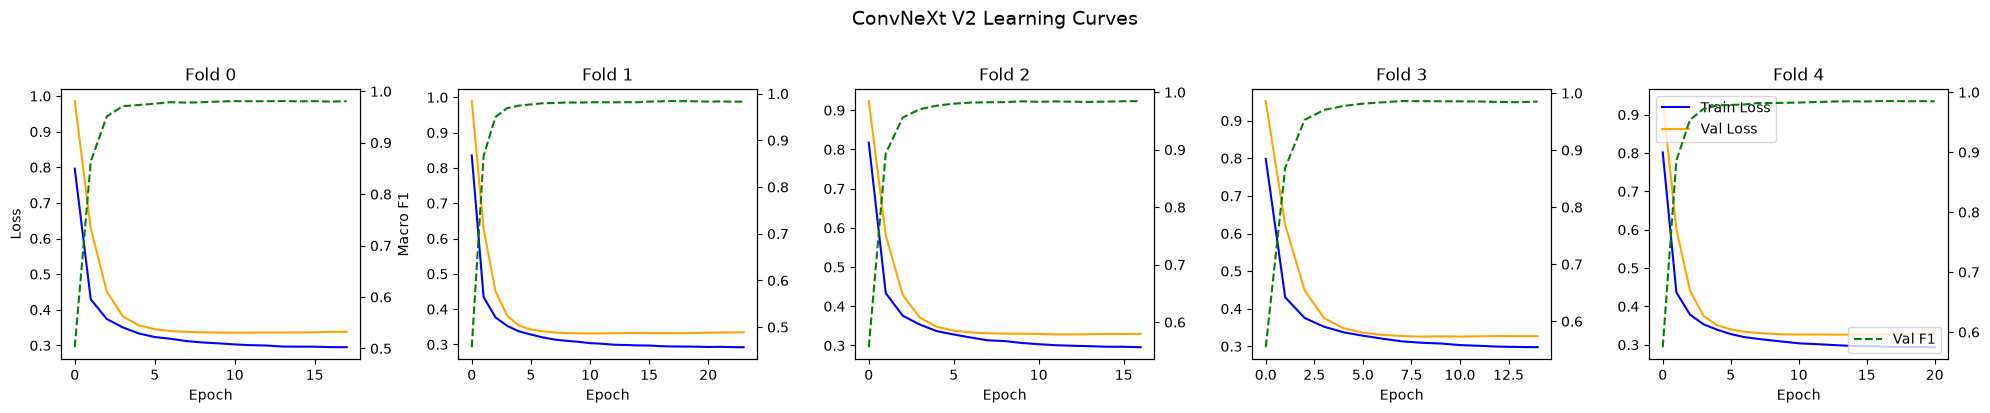


DINOv2 DIAGNOSTICS
Final 5-Fold CV Score (DINOv2): 0.9799 +/- 0.0018

Per-Fold Per-Class F1:
Fold   Recyclable   Electronic   Organic      Macro   
----------------------------------------------------
0      0.9675       0.9880       0.9745       0.9767  
1      0.9703       0.9930       0.9770       0.9801  
2      0.9735       0.9899       0.9807       0.9814  
3      0.9711       0.9887       0.9790       0.9796  
4      0.9736       0.9924       0.9798       0.9819  


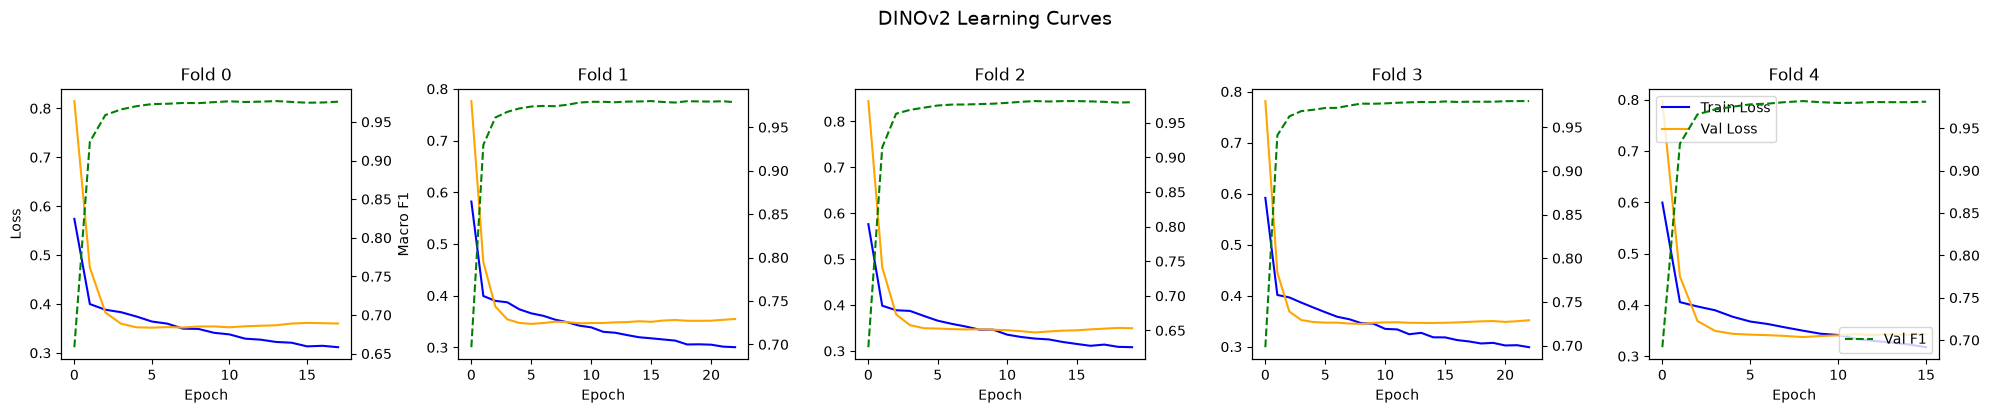

In [20]:
# Cell 19 - CV Results Summary
# Displays 5-fold CV scores, learning curves, and per-fold per-class F1 breakdown.

def plot_cv_results(fold_results, model_name):
    cv_scores = [fold_results[f]["best_f1"] for f in range(N_SPLITS)]
    mean_cv = np.mean(cv_scores)
    std_cv  = np.std(cv_scores)

    print(f"Final 5-Fold CV Score ({model_name}): {mean_cv:.4f} +/- {std_cv:.4f}\n")

    print("Per-Fold Per-Class F1:")
    print(f"{'Fold':<6} {'Recyclable':<12} {'Electronic':<12} {'Organic':<12} {'Macro':<8}")
    print("-" * 52)
    for f in range(N_SPLITS):
        pc_f1 = fold_results[f]["best_per_class_f1"]
        print(f"{f:<6} {pc_f1[0]:<12.4f} {pc_f1[1]:<12.4f} {pc_f1[2]:<12.4f} {fold_results[f]['best_f1']:<8.4f}")

    fig, axes = plt.subplots(1, N_SPLITS, figsize=(4 * N_SPLITS, 4))
    for f in range(N_SPLITS):
        ax = axes[f]
        hist = fold_results[f]["history"]
        ax.plot(hist["train_loss"], label="Train Loss", color="blue")
        ax.plot(hist["val_loss"], label="Val Loss", color="orange")
        
        ax2 = ax.twinx()
        ax2.plot(hist["val_macro_f1"], label="Val F1", color="green", linestyle="--")
        
        ax.set_title(f"Fold {f}")
        ax.set_xlabel("Epoch")
        if f == 0:
            ax.set_ylabel("Loss")
            ax2.set_ylabel("Macro F1")
        if f == N_SPLITS - 1:
            ax.legend(loc="upper left")
            ax2.legend(loc="lower right")

    plt.suptitle(f"{model_name} Learning Curves", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

print("CONVNEXT V2 DIAGNOSTICS")
plot_cv_results(convnext_fold_results, "ConvNeXt V2")

print("\nDINOv2 DIAGNOSTICS")
plot_cv_results(dinov2_fold_results, "DINOv2")

CONVNEXT V2 OOF ANALYSIS
Overall OOF Macro F1 (ConvNeXt V2): 0.9839

Per-Class Metrics (OOF):
Class          Precision  Recall     F1        
--------------------------------------------
Recyclable     0.9752     0.9777     0.9764    
Electronic     0.9905     0.9962     0.9933    
Organic        0.9838     0.9799     0.9819    


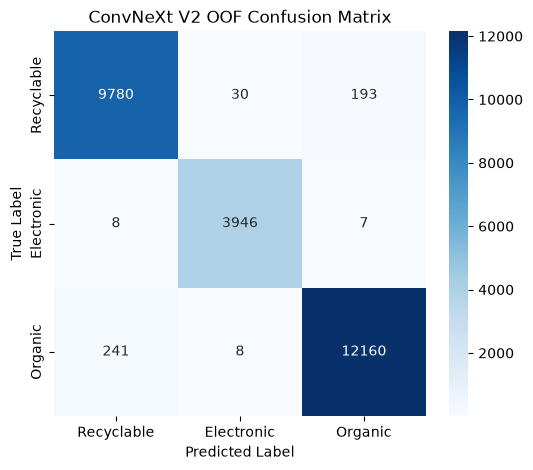


Total OOF Errors: 487 / 26373
High Confidence Errors (>85%): 180


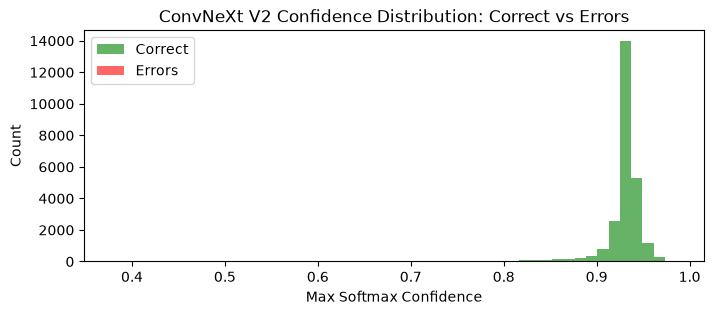


DINOv2 OOF ANALYSIS
Overall OOF Macro F1 (DINOv2): 0.9799

Per-Class Metrics (OOF):
Class          Precision  Recall     F1        
--------------------------------------------
Recyclable     0.9689     0.9735     0.9712    
Electronic     0.9899     0.9909     0.9904    
Organic        0.9803     0.9761     0.9782    


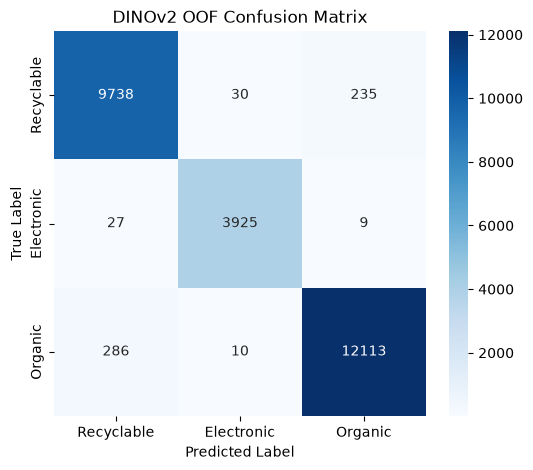


Total OOF Errors: 597 / 26373
High Confidence Errors (>85%): 437


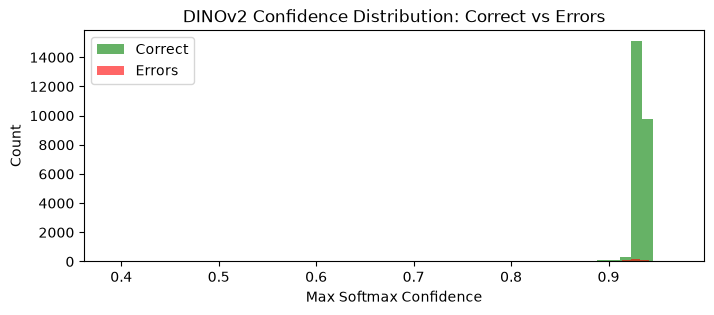

In [21]:
# Cell 20 - OOF Analysis and Confusion Matrix
# Analyzes out-of-fold predictions, per-class metrics, and confidence distributions.

def analyze_oof(oof_probs, oof_labels, model_name):
    valid_oof_mask = oof_labels != -1
    valid_oof_probs  = oof_probs[valid_oof_mask]
    valid_oof_labels = oof_labels[valid_oof_mask]
    valid_oof_preds  = np.argmax(valid_oof_probs, axis=1)

    oof_macro_f1 = f1_score(valid_oof_labels, valid_oof_preds, average="macro")
    f1_per_class = f1_score(valid_oof_labels, valid_oof_preds, average=None)

    print(f"Overall OOF Macro F1 ({model_name}): {oof_macro_f1:.4f}\n")

    print("Per-Class Metrics (OOF):")
    print(f"{'Class':<14} {'Precision':<10} {'Recall':<10} {'F1':<10}")
    print("-" * 44)
    for i, name in LABEL_MAP.items():
        p = precision_score(valid_oof_labels, valid_oof_preds, labels=[i], average=None, zero_division=0)[0]
        r = recall_score(valid_oof_labels, valid_oof_preds, labels=[i], average=None, zero_division=0)[0]
        f = f1_per_class[i]
        print(f"{name:<14} {p:<10.4f} {r:<10.4f} {f:<10.4f}")

    cm = confusion_matrix(valid_oof_labels, valid_oof_preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=[LABEL_MAP[i] for i in range(3)], 
                yticklabels=[LABEL_MAP[i] for i in range(3)])
    plt.title(f"{model_name} OOF Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    confidences = np.max(valid_oof_probs, axis=1)
    errors_mask = valid_oof_preds != valid_oof_labels
    high_conf_errors = (errors_mask) & (confidences > 0.85)

    print(f"\nTotal OOF Errors: {errors_mask.sum()} / {len(valid_oof_preds)}")
    print(f"High Confidence Errors (>85%): {high_conf_errors.sum()}")

    plt.figure(figsize=(8, 3))
    correct_conf = confidences[~errors_mask]
    error_conf = confidences[errors_mask]
    plt.hist(correct_conf, bins=50, alpha=0.6, label="Correct", color="green")
    plt.hist(error_conf, bins=50, alpha=0.6, label="Errors", color="red")
    plt.xlabel("Max Softmax Confidence")
    plt.ylabel("Count")
    plt.title(f"{model_name} Confidence Distribution: Correct vs Errors")
    plt.legend()
    plt.show()

print("CONVNEXT V2 OOF ANALYSIS")
analyze_oof(convnext_oof_probs, convnext_oof_labels, "ConvNeXt V2")

print("\nDINOv2 OOF ANALYSIS")
analyze_oof(dinov2_oof_probs, dinov2_oof_labels, "DINOv2")

Grid Search Complete. Optimal weight found.
  ConvNeXt Weight: 0.57
  DINOv2 Weight  : 0.43
  Best OOF Macro F1: 0.9844
  Baseline (50:50) OOF Macro F1: 0.9831
  Improvement: +0.0012


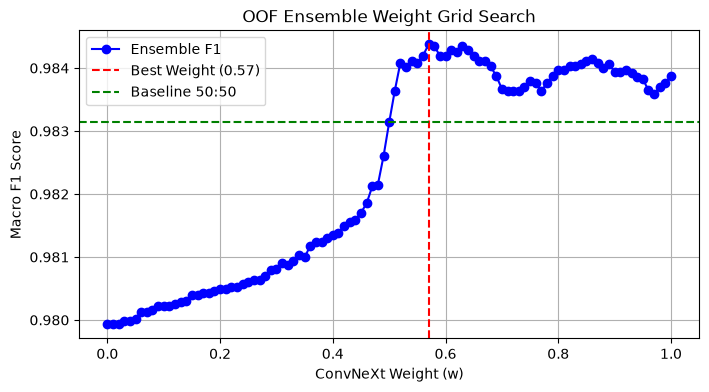

In [ ]:
# Cell 21 - Grid Search Ensemble Weight (OOF Optimization)
valid_mask = convnext_oof_labels != -1
valid_cnn_probs = convnext_oof_probs[valid_mask]
valid_vit_probs = dinov2_oof_probs[valid_mask]
valid_labels = convnext_oof_labels[valid_mask]

# Sanity check alignment
assert np.array_equal(valid_labels, dinov2_oof_labels[valid_mask]), "OOF labels mismatch between models!"

weights = []
scores = []
best_w = 0.5
best_f1 = 0.0

for w in np.arange(0.0, 1.01, 0.01):
    w = round(w, 2)
    ensemble_probs = (w * valid_cnn_probs) + ((1.0 - w) * valid_vit_probs)
    ensemble_preds = np.argmax(ensemble_probs, axis=1)
    f1 = f1_score(valid_labels, ensemble_preds, average="macro")
    
    weights.append(w)
    scores.append(f1)
    
    if f1 > best_f1:
        best_f1 = f1
        best_w = w
        
# Update global config to use optimal weight for final submission
ENSEMBLE_WEIGHT_CNN = best_w
ENSEMBLE_WEIGHT_VIT = 1.0 - best_w

print("Grid Search Complete. Optimal weight found.")
print(f"  ConvNeXt Weight: {ENSEMBLE_WEIGHT_CNN:.2f}")
print(f"  DINOv2 Weight  : {ENSEMBLE_WEIGHT_VIT:.2f}")
print(f"  Best OOF Macro F1: {best_f1:.4f}")

baseline_f1 = f1_score(valid_labels, np.argmax(0.5 * valid_cnn_probs + 0.5 * valid_vit_probs, axis=1), average="macro")
print(f"  Baseline (50:50) OOF Macro F1: {baseline_f1:.4f}")
print(f"  Improvement: +{(best_f1 - baseline_f1):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(weights, scores, marker='o', color='b', label='Ensemble F1')
plt.axvline(x=best_w, color='r', linestyle='--', label=f'Best Weight ({best_w:.2f})')
plt.axhline(y=baseline_f1, color='g', linestyle='--', label='Baseline 50:50')
plt.title("OOF Ensemble Weight Grid Search")
plt.xlabel("ConvNeXt Weight (w)")
plt.ylabel("Macro F1 Score")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Cell 22 - TTA Transforms & Memory Pre-loader
# 8-Pass TTA for CNN (equivariant), 5-Pass TTA for ViT (no 90deg rotations).

def get_tta_transforms(img_size, model_type="cnn"):
    normalize = T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    base_resize = T.Resize((img_size, img_size), interpolation=InterpolationMode.BICUBIC)
    to_tensor = T.ToTensor()

    def p(img): return normalize(to_tensor(base_resize(img)))

    def p0_orig(img):     return p(img)
    def p1_hflip(img):    return p(TF.hflip(img))
    def p2_vflip(img):    return p(TF.vflip(img))
    def p3_rot90(img):    return p(TF.rotate(img, 90))
    def p4_rot180(img):   return p(TF.rotate(img, 180))
    def p5_rot270(img):   return p(TF.rotate(img, 270))
    def p6_crop(img):
        w, h = img.size
        return p(TF.center_crop(img, int(min(w, h) * 0.9)))
    def p7_crop_hf(img):
        w, h = img.size
        return p(TF.hflip(TF.center_crop(img, int(min(w, h) * 0.9))))

    if model_type == "cnn":
        return [
            ('orig', p0_orig), ('hflip', p1_hflip), ('vflip', p2_vflip), 
            ('rot90', p3_rot90), ('rot180', p4_rot180), ('rot270', p5_rot270), 
            ('crop', p6_crop), ('crop_hf', p7_crop_hf)
        ]
    elif model_type == "vit":
        return [
            ('orig', p0_orig), ('hflip', p1_hflip), ('vflip', p2_vflip), 
            ('crop', p6_crop), ('crop_hf', p7_crop_hf)
        ]
    else:
        raise ValueError(f"Unknown model_type for TTA: {model_type}")
    
# Pre-load all test images into memory to avoid repeated disk reads
print("Pre-loading test images into memory...")
test_pil_images = []
for idx, row in submission_df.iterrows():
    try:
        img = Image.open(row["filepath"]).convert('RGB')
    except Exception as e:
        logger.error(f"Error loading {row['filepath']}: {e}")
        # Fallback to expected size to prevent shape mismatch crashes
        img = Image.new('RGB', (IMG_SIZE_CNN, IMG_SIZE_CNN), (0, 0, 0))
    test_pil_images.append(img)
print(f"Loaded {len(test_pil_images)} test images into memory.")

class PreloadedTTADataset(Dataset):
    def __init__(self, images, transform):
        self.images = images
        self.transform = transform
        
    def __len__(self): return len(self.images)
    def __getitem__(self, i): return self.transform(self.images[i])

Pre-loading test images into memory...
Loaded 1458 test images into memory.


In [26]:
# Cell 23 - TTA Runner
# TTA Inference Runner with strict checkpoint validation.

@torch.no_grad()
def run_tta_inference(model_name, img_size, prefix, batch_size, model_type):
    tta_tfms = get_tta_transforms(img_size, model_type)
    
    chkpt_paths = [OUTPUT_DIR / f"{prefix}_fold{fold}_best.pt" for fold in range(N_SPLITS)]
    for chkpt in chkpt_paths:
        assert chkpt.exists(), f"Missing checkpoint: {chkpt}. Cannot perform TTA."
        
    all_probs = np.zeros((len(submission_df), 3), dtype=np.float32)
    
    for fold, chkpt in enumerate(chkpt_paths):
        print(f"\nRunning {len(tta_tfms)}-Pass TTA for {prefix} Fold {fold}...")
        
        model = build_model(model_name, pretrained=False, img_size=img_size)
        
        # FIX: Tambahkan weights_only=False karena kita menyimpan numpy array di checkpoint
        state_dict = torch.load(chkpt, map_location=DEVICE, weights_only=False)
        
        if "model_state_dict" in state_dict:
            model.load_state_dict(state_dict["model_state_dict"])
        else:
            model.load_state_dict(state_dict)
            
        model.eval().to(DEVICE)
        
        fold_probs = np.zeros((len(submission_df), 3), dtype=np.float32)
        
        for name, tfm in tta_tfms:
            loader = DataLoader(
                PreloadedTTADataset(test_pil_images, tfm), 
                batch_size=batch_size, 
                shuffle=False, 
                num_workers=0,  
                pin_memory=True
            )
            pass_probs = []
            
            for imgs in loader:
                with torch.amp.autocast('cuda'):
                    probs = torch.softmax(model(imgs.to(DEVICE)), dim=1)
                pass_probs.append(probs.cpu().numpy())
                
            fold_probs += np.concatenate(pass_probs, axis=0)
            
        fold_probs /= len(tta_tfms)
        all_probs += fold_probs
        
        del model
        torch.cuda.empty_cache()
        
    all_probs /= N_SPLITS
    return all_probs

In [27]:
# Cell 24 - EXECUTION: ConvNeXt TTA
# 8-Pass TTA for ConvNeXt V2
print("Extracting ConvNeXt probabilities...")
probs_convnext = run_tta_inference(
    model_name=MODEL_NAME_CNN, 
    img_size=IMG_SIZE_CNN, 
    prefix="convnext", 
    batch_size=BATCH_SIZE_CNN, 
    model_type="cnn"
)
np.save(OUTPUT_DIR / "probs_convnext.npy", probs_convnext)
print("Saved probs_convnext.npy")

Extracting ConvNeXt probabilities...

Running 8-Pass TTA for convnext Fold 0...

Running 8-Pass TTA for convnext Fold 1...

Running 8-Pass TTA for convnext Fold 2...

Running 8-Pass TTA for convnext Fold 3...

Running 8-Pass TTA for convnext Fold 4...
Saved probs_convnext.npy


In [28]:
# Cell 25 - EXECUTION: DINOv2 TTA
# 5-Pass TTA for DINOv2
print("Extracting DINOv2 probabilities...")
probs_dinov2 = run_tta_inference(
    model_name=MODEL_NAME_VIT, 
    img_size=IMG_SIZE_VIT, 
    prefix="dinov2", 
    batch_size=BATCH_SIZE_VIT, 
    model_type="vit"
)
np.save(OUTPUT_DIR / "probs_dinov2.npy", probs_dinov2)
print("Saved probs_dinov2.npy")

Extracting DINOv2 probabilities...

Running 5-Pass TTA for dinov2 Fold 0...

Running 5-Pass TTA for dinov2 Fold 1...

Running 5-Pass TTA for dinov2 Fold 2...

Running 5-Pass TTA for dinov2 Fold 3...

Running 5-Pass TTA for dinov2 Fold 4...
Saved probs_dinov2.npy


In [29]:
# Cell 26 - Ensemble Averaging & Hash Override

print(f"Ensembling {ENSEMBLE_WEIGHT_CNN*100:.0f}% ConvNeXt + {ENSEMBLE_WEIGHT_VIT*100:.0f}% DINOv2...")
probs_ensemble = (ENSEMBLE_WEIGHT_CNN * probs_convnext) + (ENSEMBLE_WEIGHT_VIT * probs_dinov2)

filename_to_corrected_label = dict(zip(train_master["filename"], train_master["label"]))

override_map = {}
for _, row in overlap_df.iterrows():
    test_id = int(row["test_id"])
    train_fn = row["train_filename"]
    
    if train_fn in filename_to_corrected_label:
        true_cls = filename_to_corrected_label[train_fn]
    else:
        true_cls = LABEL_TO_IDX[str(row["train_label"])]
        
    override_map[test_id] = true_cls

override_count = 0
for idx, row in submission_df.iterrows():
    test_id = int(row["id"])
    if test_id in override_map:
        true_cls = override_map[test_id]
        probs_ensemble[idx] = 0.0
        probs_ensemble[idx, true_cls] = 1.0
        override_count += 1
        
print(f"Applied {override_count} Hash Overrides.")

np.save(OUTPUT_DIR / "probs_ensemble.npy", probs_ensemble)

predictions = np.argmax(probs_ensemble, axis=1)

Ensembling 57% ConvNeXt + 43% DINOv2...
Applied 97 Hash Overrides.


In [30]:
# Cell 27 - Pre-Submission Validation

assert len(predictions) == EXPECTED_TEST_COUNT, f"Row count mismatch! Expected {EXPECTED_TEST_COUNT}, got {len(predictions)}"

unique_preds = set(np.unique(predictions))
assert unique_preds.issubset({0, 1, 2}), f"Invalid labels generated: {unique_preds}"

assert list(submission_df["id"]) == list(range(1, EXPECTED_TEST_COUNT + 1)), "Row order corrupted! Submission will be invalid."

# Verify overrides were applied correctly
for idx, row in submission_df.iterrows():
    img_id = int(row["id"])
    if img_id in override_map:
        assert predictions[idx] == override_map[img_id], f"Override failed for ID {img_id}"

# Check distribution shift
pred_dist = pd.Series(predictions).value_counts(normalize=True).sort_index()
valid_train = train_master[(~train_master["exclude_from_cv"]) & (~train_master["exclude_from_training"])]
train_dist = valid_train["label"].value_counts(normalize=True).sort_index()
dist_shift = (pred_dist - train_dist).abs()

print("Prediction vs Training distribution:")
print(f"{'Class':<14} {'Train':<8} {'Pred':<8} {'Shift':<8}")
for i, name in LABEL_MAP.items():
    print(f"{name:<14} {train_dist[i]:<8.1%} {pred_dist[i]:<8.1%} {dist_shift[i]:<8.1%}")
    
max_shift = dist_shift.max()
if max_shift > 0.05:
    print("\nWARNING: Distribution shift > 5% - Note: this is expected as pred_dist includes 97 overrides while train_dist excludes them.")

print("\nALL PRE-SUBMISSION SANITY CHECKS PASSED.")

Prediction vs Training distribution:
Class          Train    Pred     Shift   
Recyclable     37.9%    35.5%    2.4%    
Electronic     15.0%    13.9%    1.2%    
Organic        47.1%    50.6%    3.6%    

ALL PRE-SUBMISSION SANITY CHECKS PASSED.


In [31]:
# Cell 28 - Generate Final Submission CSV
# Fase 5: Write final predictions to CSV and save metadata/checksum.

submission_df["predicted"] = predictions
output_path = OUTPUT_DIR / "submission_v6_ensemble.csv"

final_df = submission_df[["id", "predicted"]].copy()
final_df.to_csv(output_path, index=False)

print(f"FINAL SUBMISSION SAVED: {output_path}")

print("\nSubmission Preview (first 10 rows):")
print(final_df.head(10).to_string(index=False))

print("\nFinal Prediction Distribution:")
dist = final_df["predicted"].value_counts().sort_index()
for lbl, cnt in dist.items():
    print(f"  {LABEL_MAP[lbl]:12s}: {cnt:4,} ({cnt/EXPECTED_TEST_COUNT:.1%})")

# Generate checksum and metadata
with open(output_path, "rb") as f:
    file_hash = hashlib.md5(f.read()).hexdigest()
print(f"\nSubmission MD5: {file_hash}")

# Calculate mean CV scores for metadata
mean_cv_convnext = np.mean([convnext_fold_results[f]["best_f1"] for f in range(N_SPLITS)])
mean_cv_dinov2 = np.mean([dinov2_fold_results[f]["best_f1"] for f in range(N_SPLITS)])

metadata = {
    "run_id": RUN_ID,
    "timestamp": pd.Timestamp.now().isoformat(),
    "models": {
        "convnext": {
            "cv_mean_f1": mean_cv_convnext,
            "img_size": IMG_SIZE_CNN,
            "backbone_lr": BACKBONE_LR_CNN,
            "tta_passes": TTA_PASSES_CNN
        },
        "dinov2": {
            "cv_mean_f1": mean_cv_dinov2,
            "img_size": IMG_SIZE_VIT,
            "backbone_lr": BACKBONE_LR_VIT,
            "tta_passes": TTA_PASSES_VIT
        }
    },
    "ensemble_weights": {
        "convnext": ENSEMBLE_WEIGHT_CNN,
        "dinov2": ENSEMBLE_WEIGHT_VIT
    },
    "seed": SEED,
    "submission_md5": file_hash,
    "row_count": len(final_df),
    "overrides_applied": override_count
}
with open(OUTPUT_DIR / "submission_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print("Metadata saved -> submission_metadata.json")

FINAL SUBMISSION SAVED: /workspace/satria-data-bdc/outputs/submission_v6_ensemble.csv

Submission Preview (first 10 rows):
 id  predicted
  1          2
  2          2
  3          2
  4          1
  5          0
  6          0
  7          2
  8          0
  9          1
 10          2

Final Prediction Distribution:
  Recyclable  :  518 (35.5%)
  Electronic  :  202 (13.9%)
  Organic     :  738 (50.6%)

Submission MD5: 9574847bc20ff17394ddba1e818c181e
Metadata saved -> submission_metadata.json


In [ ]:
# Cell 29 - OOF Error Analysis DataFrame Generation

print("Generating OOF Error Analysis DataFrame...")

# Create a dataframe from the OOF probabilities
oof_df = train_master.copy()

# Calculate ensemble OOF probabilities
oof_probs_ensemble = (ENSEMBLE_WEIGHT_CNN * convnext_oof_probs) + (ENSEMBLE_WEIGHT_VIT * dinov2_oof_probs)

# Extract OOF predictions and confidence
oof_df['pred_label'] = np.argmax(oof_probs_ensemble, axis=1)
oof_df['pred_confidence'] = np.max(oof_probs_ensemble, axis=1)
oof_df['gt_prob'] = oof_probs_ensemble[np.arange(len(oof_df)), oof_df['label']]


oof_df = oof_df[
    (oof_df['exclude_from_training'] == False) &
    (oof_df['exclude_from_cv'] == False)
].copy()
oof_df['is_correct'] = oof_df['pred_label'] == oof_df['label']

oof_df['is_relabeled'] = oof_df['label_folder'].map(LABEL_TO_IDX) != oof_df['label']

print(f"OOF Analysis DataFrame generated. Total evaluated rows: {len(oof_df)}")
print(oof_df[['filename', 'label', 'pred_label', 'pred_confidence', 'is_correct', 'is_relabeled']].head())

Generating OOF Error Analysis DataFrame...
OOF Analysis DataFrame generated. Total evaluated rows: 26373
     filename  label  pred_label  pred_confidence  is_correct  is_relabeled
0     R_1.jpg      0           0         0.933530        True         False
1    R_10.jpg      0           0         0.931504        True         False
2   R_100.jpg      0           0         0.946050        True         False
3  R_1000.jpg      0           0         0.935693        True         False
4  R_1001.jpg      0           0         0.925522        True         False


In [ ]:
# Cell 30 - Save OOF High-Confidence Errors for Manual Review

print("Filtering and saving high-confidence OOF errors for manual review...")

# Filter for errors
errors_df = oof_df[~oof_df['is_correct']].copy()

# Sort by confidence (highest confidence errors first - most likely label noise)
errors_df = errors_df.sort_values(by='pred_confidence', ascending=False)

# Select relevant columns for manual review
error_report = errors_df[[
    'filename', 'filepath', 'label_folder', 'label', 'pred_label', 'pred_confidence', 'gt_prob', 'is_relabeled'
]].rename(columns={
    'label_folder': 'original_label_folder',
    'label': 'current_label',
    'pred_label': 'oof_pred'
})

output_csv = OUTPUT_DIR / "oof_high_confidence_errors.csv"
error_report.to_csv(output_csv, index=False)

print(f"Saved {len(error_report)} OOF errors to {output_csv}.")
print("\nTop 15 highest confidence OOF errors (candidates for relabeling in Sub 2/3):")
print(error_report.head(15).to_string(index=False))

Filtering and saving high-confidence OOF errors for manual review...
Saved 477 OOF errors to /workspace/satria-data-bdc/outputs/oof_high_confidence_errors.csv.

Top 15 highest confidence OOF errors (candidates for relabeling in Sub 2/3):
   filename                                                 filepath original_label_folder  current_label  oof_pred  pred_confidence  gt_prob  is_relabeled
  O_289.jpg     /workspace/satria-data-bdc/train/2_Organic/O_289.jpg             2_Organic              2         0         0.951543 0.026396         False
 O_9926.jpg    /workspace/satria-data-bdc/train/2_Organic/O_9926.jpg             2_Organic              2         0         0.950420 0.025388         False
 R_4675.jpg /workspace/satria-data-bdc/train/0_Recyclable/R_4675.jpg          0_Recyclable              0         2         0.945615 0.029345         False
  R_539.jpg  /workspace/satria-data-bdc/train/0_Recyclable/R_539.jpg          0_Recyclable              0         2         0.945557 0.026